# Predicting Shipping Costs for Pre-Shipment Quotes

**Business objective.** Help freight brokers estimate the expected cost of a shipment before providing a quote to the customer, using only information available at quote time. This will allow brokers to prepare more accurate customer quotes. Because final shipping costs can vary, the model will provide an estimated **cost range** rather than only a single value.

**Notebook sequence**

1. Understanding the Data
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Modeling: baseline and three candidate models
6. Fine-Tuning
7. Model Selection
8. Prediction Intervals and Quote Example

> Important: post-shipment variables (actual departure/arrival, realized revenue/expense/profit, status, invoice results) are not used as predictors.

## Setup

In [1]:
# If needed, install dependencies once in your environment:
# %pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

# 1. Understanding the Data

The purpose of this section is to understand the structure, coverage, and meaning of the source data before making any changes. At this stage, the dataset is only loaded and inspected; no cleaning decisions are applied.

### 1.1 Load the dataset

In [2]:
DATA_PATH = Path(
    r"C:\Users\thati\OneDrive\Documentos\Regis\12_Practicum II\Declaration_Dec_2025_June_2026.xlsx"
)

raw_df = pd.read_excel(DATA_PATH)
raw_df.head()

,Declaration ID,Cancel,Trans,Dec. Type,Mode,Br,Standalone,# Inv. Headers,# Inv. Lines,Origin,Final Dest.,Load,Arrival,Origin ETD,Dest. ETA,Load ATD,Arrival ATA,Dec. Registered,Supplier,Supplier Name,Importer,Importer Name,House,Master,Vessel,Voy./Flt.,Weight,Wt. UQ,Volume,Vol. UQ,Packs,Pack Type,BR,Dept,Local Client,Local Client Name,Job Sales Rep,Job Operator,Status,Job Opened,Revenue,WIP,Total Income,Cost,Accrual,Total Expense,Job Profit,Ctr Count,TEU
0,B00001490,N,AIR,IMP,NCT,DEN,Y,1,1,CHBSL,USRDU,CHBSL,USEWR,2025-11-27,2025-12-03,2025-11-27,2025-11-27,2025-12-01 15:13:00,OZDBURBSL,"OZDEMIRCAN, BURCU",OZDBURRIC,"OZDEMIRCAN, BURCU",NaN,01661565980,NaN,UA0135,268.0,KG,0.0,M3,2,PK,DEN,CIA,GRAMOVAUC,GRAEBEL MOVERS INTERNATIONAL INC,NaN,Sean Slegowski,INV,2025-12-01 15:13:00,235.00,NaN,235.00,-110.45,NaN,-110.45,124.55,0,0.0
1,B00001492,N,NaN,EXP,NaN,SFO,Y,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaT,NaT,2025-12-01 15:16:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,KG,0.0,M3,0,NaN,SFO,COT,NaN,NaN,NaN,Cortina Wong-Mah,WRK,2025-12-01 15:16:00,NaN,3.28,3.28,-3.28,NaN,-3.28,0.00,0,0.0
2,B00001493,N,SEA,IMP,CNT,IAH,Y,1,1,AOLAD,USHOU,AOLAD,USHOU,2025-10-04,2025-12-01,2025-10-04,2025-12-01,2025-12-01 15:18:00,WILJOELAD,"WILLIAMS, JOE MACK",WILJOEIAH,"WILLIAMS, JOE MACK",NaN,NLD0111961,CMA CGM DALILA,0PGM6,2384.0,KG,0.0,M3,200,PK,IAH,CIS,MIGSFO,"THE MIGROUP, SFO",NaN,Judy Vitale,INV,2025-12-01 15:18:00,751.52,NaN,751.52,-644.45,NaN,-644.45,107.07,1,1.0
3,B00001494,N,SEA,IMP,NCT,IAH,Y,1,1,BRSAO,USEWR,BRSAO,USEWR,2025-11-19,2025-12-02,2025-11-19,2025-12-02,2025-12-01 16:01:00,RIGBERSAO,"RIGATTO BERWANGER, EDUARDO",RIGBERBDR,"RIGATTO BERWANGER, EDUARDO",SSZ251114292,SS5251080180,MAERSK MONTE ALEGRE,545N,654.0,KG,0.0,M3,2,PK,IAH,CIS,TRAWORKTX,TRANSPORTATION WORLDWIDE INC,NaN,Judy Vitale,INV,2025-12-01 16:01:00,1214.06,NaN,1214.06,-990.01,NaN,-990.01,224.05,0,0.0
4,B00001495,N,SEA,IMP,CNT,DEN,Y,1,1,THBKK,USORF,THLCH,USORF,NaT,2025-11-30,2025-10-15,2025-11-30,2025-12-01 16:07:00,KENJOYBKK,"KENT, JOY",KENJOYRIC,"KENT, JOY S",NaN,260471741,SOUTHAMPTON EXPRESS,542E,2976.0,KG,0.0,M3,6,PK,DEN,CIS,DEWCOMSAN,DEWITT COMPANIES LTD,NaN,Matthew Doryland,INV,2025-12-01 16:07:00,100.00,NaN,100.00,-9.95,NaN,-9.95,90.05,0,0.0


The Excel file is loaded into `raw_df`. Keeping the word *raw* in the name is intentional: this dataframe will remain unchanged and will serve as the original reference throughout the project. The first five rows provide an initial view of how each shipment is represented.

### 1.2 Review the dimensions and data types with `info()`

In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9720 entries, 0 to 9719
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Declaration ID     9720 non-null   object        
 1   Cancel             9720 non-null   object        
 2   Trans              9249 non-null   object        
 3   Dec. Type          9720 non-null   object        
 4   Mode               9205 non-null   object        
 5   Br                 9720 non-null   object        
 6   Standalone         9720 non-null   object        
 7   # Inv. Headers     9720 non-null   int64         
 8   # Inv. Lines       9720 non-null   int64         
 9   Origin             9199 non-null   object        
 10  Final Dest.        9315 non-null   object        
 11  Load               9183 non-null   object        
 12  Arrival            9346 non-null   object        
 13  Origin ETD         7930 non-null   datetime64[ns]
 14  Dest. ET

The dataset consists of company shipment records used to support freight and customs operations. It contains **9,720 shipment records and 49 variables**. Based on `Job Opened`, the observation period runs from **December 1, 2025 through June 30, 2026**.

The 49 variables initially include **14 numerical columns** (`10 float64` and `4 int64`), **29 object/categorical columns**, and **6 date columns**. The variables describe the shipment, route, transport method, physical characteristics, operational dates, parties involved, and financial results. The project will later restrict the predictive features to information that brokers can know when preparing a quote.

### 1.3 Display all column names

In [4]:
raw_df.columns

Index(['Declaration ID', 'Cancel', 'Trans', 'Dec. Type', 'Mode', 'Br',
       'Standalone', '# Inv. Headers', '# Inv. Lines', 'Origin', 'Final Dest.',
       'Load', 'Arrival', 'Origin ETD', 'Dest. ETA', 'Load ATD', 'Arrival ATA',
       'Dec. Registered', 'Supplier', 'Supplier Name', 'Importer',
       'Importer Name', 'House', 'Master', 'Vessel', 'Voy./Flt.', 'Weight',
       'Wt. UQ', 'Volume', 'Vol. UQ', 'Packs', 'Pack Type', 'BR', 'Dept',
       'Local Client', 'Local Client Name', 'Job Sales Rep', 'Job Operator',
       'Status', 'Job Opened', 'Revenue', 'WIP', 'Total Income', 'Cost',
       'Accrual', 'Total Expense', 'Job Profit', 'Ctr Count', 'TEU'],
      dtype='object')

Displaying the complete list of columns helps identify abbreviations, inconsistent labels, financial fields, dates, and identifiers. Names will be standardized later, during cleaning, so the original source structure is documented first.

### 1.4 Confirm the shipment period

In [5]:
shipment_period = pd.Series({
    "First Job Opened": pd.to_datetime(raw_df["Job Opened"], errors="coerce").min(),
    "Last Job Opened": pd.to_datetime(raw_df["Job Opened"], errors="coerce").max(),
    "Number of Records": len(raw_df),
    "Number of Columns": raw_df.shape[1],
})
shipment_period

First Job Opened     2025-12-01 14:45:00
Last Job Opened      2026-06-30 23:36:00
Number of Records                   9720
Number of Columns                     49
dtype: object

`Job Opened` is used to describe the coverage of the dataset because it represents when the company opened the shipment job. Actual and estimated movement dates can fall outside this period and should not be used to define the dataset window.

# 2. Data Cleaning

Cleaning is performed step by step on a copy named `df`. Each check is shown before applying a correction so that every decision is traceable. The target is treated differently from predictors: a missing target cannot be invented, while missing predictor values can later be handled inside the modeling pipeline.

### 2.1 Create a working copy

In [6]:
df = raw_df.copy()
print(f"Working copy created with {df.shape[0]:,} rows and {df.shape[1]} columns.")

Working copy created with 9,720 rows and 49 columns.


All cleaning operations are applied to `df`, while `raw_df` remains unchanged. This makes the process reproducible and allows comparisons with the original source if an unexpected result appears.

### 2.2 Check exact duplicate rows

In [7]:
duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count:,}")

Exact duplicate rows: 0


An exact duplicate means that all 49 values are identical in two or more rows. The initial dataset contains **0 exact duplicates**, so no rows are removed at this step. `Declaration ID` is also unique for all 9,720 records, supporting the interpretation that each row represents a distinct declaration/shipment record.

### 2.3 Identify missing values

In [8]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": df.isna().mean().mul(100).round(2)
})
missing_summary = missing_summary[missing_summary["Missing Values"] > 0]
missing_summary = missing_summary.sort_values("Missing Percentage", ascending=False)

print(f"Total missing cells: {df.isna().sum().sum():,}")
display(missing_summary)

Total missing cells: 44,163


,Missing Values,Missing Percentage
Accrual,9082,93.44
WIP,8944,92.02
House,4986,51.30
Job Sales Rep,4728,48.64
Vessel,3828,39.38
Origin ETD,1790,18.42
Voy./Flt.,1027,10.57
Vol. UQ,898,9.24
Pack Type,812,8.35
Revenue,729,7.50


There are missing values in several groups of variables. `Accrual`, `WIP`, `House`, `Job Sales Rep`, and `Vessel` have the highest missing percentages. However, missingness does not automatically mean that a row should be deleted: some fields are optional or only apply to particular shipment types.

The target `Cost` has no missing values in the source. Missing predictors are not filled with a global median here, because calculating an imputation value before the train/test split would allow future information to influence training. Predictor imputation will be learned from training data inside the modeling pipeline.

### 2.4 Count zero values in numerical variables

In [9]:
source_numeric_cols = df.select_dtypes(include="number").columns
zero_summary = pd.DataFrame({
    "Zero Values": (df[source_numeric_cols] == 0).sum(),
    "Zero Percentage": (df[source_numeric_cols] == 0).mean().mul(100).round(2)
}).sort_values("Zero Values", ascending=False)
display(zero_summary)

,Zero Values,Zero Percentage
Volume,9085,93.47
TEU,6186,63.64
Ctr Count,6183,63.61
# Inv. Lines,1318,13.56
# Inv. Headers,1289,13.26
Weight,820,8.44
Packs,801,8.24
Job Profit,489,5.03
Cost,51,0.52
Revenue,0,0.00


Zero is different from a missing value. The company confirmed that zero weight or zero volume can be operationally valid because the applicable physical measure depends on the transport type and mode. Similarly, a shipment may legitimately have zero TEU or zero containers when it is not containerized. These structural zeros are retained as observed values; they are not converted to missing values and the corresponding rows are not removed.

The company confirmed that `Cost = 0` corresponds to cancelled shipments. These records do not represent completed, billable shipments and are excluded from the analytical dataset. A cost magnitude of `$9.95` is also a provisional operational value used when billing has not been completed because information is still missing. It is not a final transportation cost and must also be excluded. The raw rows remain preserved in `raw_df`.

### 2.5 Standardize date variables

In [10]:
date_cols = [
    "Origin ETD", "Dest. ETA", "Load ATD", "Arrival ATA",
    "Dec. Registered", "Job Opened"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_cols].dtypes

Origin ETD         datetime64[ns]
Dest. ETA          datetime64[ns]
Load ATD           datetime64[ns]
Arrival ATA        datetime64[ns]
Dec. Registered    datetime64[ns]
Job Opened         datetime64[ns]
dtype: object

All six date fields are explicitly converted to `datetime`. Invalid date strings, if present, become missing values rather than causing silent calculation errors.

In the initial cleaning, missing `Origin ETD` and `Dest. ETA` were completed using `Load ATD` and `Arrival ATA`. That imputation is not applied here because actual departure and arrival information may only be known after the quote. Keeping estimated and actual dates separate prevents leakage and preserves their business meaning.

### 2.6 Standardize numerical variables

In [11]:
numeric_cols = [
    "# Inv. Headers", "# Inv. Lines", "Weight", "Volume", "Packs",
    "Revenue", "WIP", "Total Income", "Cost", "Accrual",
    "Total Expense", "Job Profit", "Ctr Count", "TEU"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols].dtypes

# Inv. Headers      int64
# Inv. Lines        int64
Weight            float64
Volume            float64
Packs               int64
Revenue           float64
WIP               float64
Total Income      float64
Cost              float64
Accrual           float64
Total Expense     float64
Job Profit        float64
Ctr Count           int64
TEU               float64
dtype: object

The numerical variables are converted explicitly so arithmetic and modeling operations behave consistently. Values that cannot be interpreted as numbers become missing and remain visible in subsequent checks.

Financial variables such as `Revenue`, `Total Expense`, `Total Income`, and `Job Profit` are not median-imputed because they are realized outcomes. They are also excluded from the predictive features because they would not be available when the broker prepares the quote.

### 2.7 Clean categorical text and inspect its categories

In [12]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in categorical_cols:
    df[col] = df[col].astype("string").str.strip().replace({"": pd.NA})

category_summary = pd.DataFrame({
    "Unique Categories": df[categorical_cols].nunique(dropna=True),
    "Missing Values": df[categorical_cols].isna().sum()
}).sort_values("Unique Categories", ascending=False)
display(category_summary)

,Unique Categories,Missing Values
Declaration ID,9720,0
Master,8846,602
House,4648,4986
Supplier,4135,544
Supplier Name,4097,544
Importer,3687,331
Importer Name,3674,331
Voy./Flt.,2945,1027
Vessel,1398,3828
Origin,1176,521


Leading and trailing spaces are removed before counting categories. This prevents labels such as `AIR` and `AIR ` from being treated as different categories. The table also identifies high-cardinality fields such as shipment identifiers, supplier/importer names, and document numbers; these should not automatically be one-hot encoded because they can cause memorization and an excessive number of model columns.

### 2.8 Review the main operational categories

In [13]:
main_category_cols = [
    "Trans", "Dec. Type", "Mode", "Br", "Standalone",
    "Wt. UQ", "Vol. UQ", "Pack Type", "Status"
]

for col in main_category_cols:
    print()
    print(col)
    display(df[col].value_counts(dropna=False).to_frame("Records"))


Trans


,Records
Trans,
SEA,5948
AIR,2926
<NA>,471
TRK,321
RAI,44
ROA,4
PHC,3
MAI,2
AUT,1



Dec. Type


,Records
Dec. Type,
IMP,9219
MSC,437
EXP,57
DRW,6
IMX,1



Mode


...

,Records
Vol. UQ,
M3,8799
<NA>,898
CF,21
KG,1
CI,1



Pack Type


,Records
Pack Type,
PK,3856
CT,2599
PC,818
<NA>,812
CTN,567
PKG,524
BG,176
PAL,109
CS,77



Status


,Records
Status,
INV,9028
WRK,677
CMP,15


This review makes the actual category labels visible before encoding. It is especially important for transport type, shipment mode, branch, measurement units, and package type. Rare or unexpected labels should be confirmed with the company rather than silently merged.

### 2.9 Fill missing quote-time categories with `Unknown`

In [14]:
quote_categorical_cols = [
    "Trans", "Dec. Type", "Mode", "Br", "Standalone",
    "Origin", "Final Dest.", "Load", "Arrival", "Pack Type"
]

for col in quote_categorical_cols:
    df[col] = df[col].fillna("Unknown")

df[quote_categorical_cols].isna().sum()

Trans          0
Dec. Type      0
Mode           0
Br             0
Standalone     0
Origin         0
Final Dest.    0
Load           0
Arrival        0
Pack Type      0
dtype: int64

Missing values in categorical variables expected at quote time are labeled `Unknown`. This follows the intent of the initial notebook and preserves the rows instead of deleting shipments. `Unknown` is a real modeling category indicating that the information was unavailable.

Names and post-shipment operational fields are not filled indiscriminately because they are not part of the initial quote-time model.

### 2.10 Convert binary fields

In [15]:
binary_mapping = {"Y": 1, "N": 0}
df["Cancel"] = df["Cancel"].map(binary_mapping).astype("Int64")
df["Standalone"] = df["Standalone"].map(binary_mapping).astype("Int64")

df[["Cancel", "Standalone"]].value_counts(dropna=False)

Cancel  Standalone
0       1             9695
        0               25
Name: count, dtype: int64

`Cancel` and `Standalone` are binary indicators, so `Y` is converted to `1` and `N` to `0`. In this extract, `Cancel` contains only `N`, meaning it has no variability and will not help distinguish costs. `Standalone` is retained because both categories are present, although one is rare.

### 2.11 Normalize weight and volume units

In [16]:
weight_factor_to_kg = {"KG": 1.0, "LB": 0.45359237, "T": 1000.0}
volume_factor_to_m3 = {"M3": 1.0, "CF": 0.0283168466}

df["Weight kg"] = np.where(
    df["Weight"].eq(0),
    0.0,
    df["Weight"] * df["Wt. UQ"].map(weight_factor_to_kg)
)
df["Volume m3"] = np.where(
    df["Volume"].eq(0),
    0.0,
    df["Volume"] * df["Vol. UQ"].map(volume_factor_to_m3)
)

display(df[["Weight", "Wt. UQ", "Weight kg", "Volume", "Vol. UQ", "Volume m3"]].head(10))

,Weight,Wt. UQ,Weight kg,Volume,Vol. UQ,Volume m3
0,268.0,KG,268.0,0.0,M3,0.0
1,0.0,KG,0.0,0.0,M3,0.0
2,2384.0,KG,2384.0,0.0,M3,0.0
3,654.0,KG,654.0,0.0,M3,0.0
4,2976.0,KG,2976.0,0.0,M3,0.0
5,2720.0,KG,2720.0,0.0,M3,0.0
6,391.0,KG,391.0,0.0,M3,0.0
7,60300.0,KG,60300.0,0.0,M3,0.0
8,60300.0,KG,60300.0,0.0,M3,0.0
9,4346.0,KG,4346.0,0.0,M3,0.0


Weight is converted to kilograms and volume to cubic meters so the model compares shipments on a common scale. Recognized weight units are `KG`, `LB`, and `T`; recognized volume units are `M3` and `CF`.

Confirmed operational zeros remain exactly `0`, even if their unit field is blank, because zero weight or volume may legitimately indicate that the measure does not apply to that transport type or mode. A positive measurement with an invalid or missing unit remains missing after normalization and will be handled inside the modeling pipeline.

### 2.12 Create the positive transportation-cost target

In [17]:
# First retain only shipments whose billing status is invoiced/finalized.
rows_before_status_filter = len(df)
df = df[df["Status"] == "INV"].copy()

print(f"Rows before Status filter: {rows_before_status_filter:,}")
print(f"Rows with Status = INV: {len(df):,}")
print(f"Non-invoiced rows excluded: {rows_before_status_filter - len(df):,}")

Rows before Status filter: 9,720
Rows with Status = INV: 9,028
Non-invoiced rows excluded: 692


Only records with `Status = INV` are retained because these shipments have reached the invoicing stage and therefore provide the most reliable representation of the final billed cost. `WRK` and `CMP` records may still contain incomplete or provisional amounts. `Status` is used only to select trustworthy historical labels; it will not be used as a predictive feature because the broker does not know the final status when preparing the quote.

### 2.13 Exclude zero and provisional costs

In [18]:
provisional_cost = 9.95
zero_cost_rows = df["Cost"].eq(0).sum()
provisional_cost_rows = np.isclose(
    df["Cost"].abs(), provisional_cost, atol=0.001
).sum()

df = df[
    df["Cost"].ne(0)
    & ~np.isclose(df["Cost"].abs(), provisional_cost, atol=0.001)
].copy()

print(f"Zero-cost rows excluded: {zero_cost_rows:,}")
print(f"Provisional $9.95 rows excluded: {provisional_cost_rows:,}")
print(f"Rows remaining: {len(df):,}")

Zero-cost rows excluded: 51
Provisional $9.95 rows excluded: 1,810
Rows remaining: 7,167


According to the company’s operational process, `Cost = 0` corresponds to cancelled shipments. They are excluded because the project aims to estimate the final cost of shipments that proceed to billing, and a cancellation is not a completed shipment outcome. A magnitude of `$9.95` is also excluded because it is a provisional placeholder used when billing cannot be completed due to missing information. Keeping cancelled or provisional records would bias the EDA and predictions downward.

### 2.14 Convert the accounting cost to a positive magnitude

In [19]:
# The negative sign is an accounting convention used in financial formulas.
df["Transportation Cost"] = df["Cost"].abs()

display(df[["Cost", "Transportation Cost"]].head(10))
display(df["Transportation Cost"].describe().to_frame())

,Cost,Transportation Cost
0,-110.45,110.45
2,-644.45,644.45
3,-990.01,990.01
6,-828.69,828.69
8,-16219.68,16219.68
9,-132.45,132.45
11,-444.33,444.33
13,-994.78,994.78
14,-720.95,720.95
15,-2733.40,2733.40


,Transportation Cost
count,7167.000000
mean,7174.507440
std,15122.119455
min,0.020000
25%,290.600000
50%,1495.370000
75%,8773.805000
max,274467.210000


Company expenses are stored as negative values so accounting formulas work correctly. For this prediction problem, the model needs the amount paid rather than its accounting sign, so `abs()` converts negative costs to positive magnitudes. Already-positive valid costs remain positive. This transformation is applied only after nonfinal, zero, and provisional costs have been removed.

### 2.15 Rename columns for readability

In [20]:
rename_map = {
    "Trans": "Transport Type", "Dec. Type": "Declaration Type", "Br": "Branch",
    "# Inv. Headers": "Invoice Headers", "# Inv. Lines": "Invoice Lines",
    "Origin": "Origin Port", "Final Dest.": "Final Destination",
    "Load": "Load Port", "Arrival": "Arrival Port",
    "Wt. UQ": "Weight Unit", "Vol. UQ": "Volume Unit",
    "Ctr Count": "Container Count", "Pack Type": "Package Type",
    "Voy./Flt.": "Voyage/Flight"
}

df = df.rename(columns=rename_map)
df.columns

Index(['Declaration ID', 'Cancel', 'Transport Type', 'Declaration Type',
       'Mode', 'Branch', 'Standalone', 'Invoice Headers', 'Invoice Lines',
       'Origin Port', 'Final Destination', 'Load Port', 'Arrival Port',
       'Origin ETD', 'Dest. ETA', 'Load ATD', 'Arrival ATA', 'Dec. Registered',
       'Supplier', 'Supplier Name', 'Importer', 'Importer Name', 'House',
       'Master', 'Vessel', 'Voyage/Flight', 'Weight', 'Weight Unit', 'Volume',
       'Volume Unit', 'Packs', 'Package Type', 'BR', 'Dept', 'Local Client',
       'Local Client Name', 'Job Sales Rep', 'Job Operator', 'Status',
       'Job Opened', 'Revenue', 'WIP', 'Total Income', 'Cost', 'Accrual',
       'Total Expense', 'Job Profit', 'Container Count', 'TEU', 'Weight kg',
       'Volume m3', 'Transportation Cost'],
      dtype='object')

Abbreviated source labels are replaced with readable names only after the source structure and categories have been documented. Clear names reduce mistakes in EDA and make the notebook easier for nontechnical stakeholders to follow.

### 2.16 Create the analysis and modeling dataset

In [21]:
rows_before = len(df)

df = (
    df.loc[df["Transportation Cost"].notna() & df["Job Opened"].notna()]
      .drop_duplicates()
      .reset_index(drop=True)
)

print(f"Rows before the final eligibility filter: {rows_before:,}")
print(f"Rows available for EDA and modeling: {len(df):,}")
print(f"Rows excluded: {rows_before - len(df):,}")

Rows before the final eligibility filter: 7,167
Rows available for EDA and modeling: 7,167
Rows excluded: 0


The final analytical dataset now contains only invoiced shipments with a nonzero, nonprovisional transportation cost and a valid `Job Opened` date. The date is required for chronological validation. Rows are not removed merely because an optional predictor is missing; those missing predictor values will be handled using training-only preprocessing.

### 2.17 Final cleaning validation

In [22]:
final_validation = pd.Series({
    "Rows": len(df),
    "Columns": df.shape[1],
    "Exact Duplicates": df.duplicated().sum(),
    "Missing Target": df["Transportation Cost"].isna().sum(),
    "Zero Target": df["Transportation Cost"].eq(0).sum(),
    "First Job Opened": df["Job Opened"].min(),
    "Last Job Opened": df["Job Opened"].max(),
})
final_validation

Rows                               7167
Columns                              52
Exact Duplicates                      0
Missing Target                        0
Zero Target                           0
First Job Opened    2025-12-01 14:45:00
Last Job Opened     2026-06-30 23:18:00
dtype: object

This final check confirms the number of usable records, verifies that the target is complete and nonzero, and documents the chronological coverage after cleaning. The remaining missing predictor values are intentional and will be handled without leakage in the feature-engineering and modeling pipeline.

# 3. Exploratory Data Analysis (EDA)

This EDA examines only the cleaned analytical dataset: invoiced shipments with a valid final cost, excluding cancelled records (`Cost = 0`) and provisional billing placeholders (`$9.95`). Each visualization answers a question relevant to pre-shipment quoting, followed immediately by a numerical interpretation calculated from the data.

Extreme values are never removed merely to improve a chart. When an axis is capped for readability, the title and code identify the display percentile, while the numerical analysis continues to use all eligible records.

In [23]:
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter, PercentFormatter

COLORS = {
    "navy": "#173F5F", "blue": "#20639B", "teal": "#3CAEA3",
    "gold": "#F6D55C", "red": "#ED553B", "gray": "#6B7280",
    "light": "#DCE6F1"
}

currency = FuncFormatter(lambda x, pos: f"${x:,.0f}")

def clean_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, linestyle="--", alpha=.25)
    ax.set_axisbelow(True)

## Visualization 1 — Distribution of Final Transportation Cost

**What is being shown?** The left panel displays final transportation costs on their original dollar scale. The right panel displays the same observations using `log1p(cost)`, making the concentration of lower-cost shipments visible without deleting expensive shipments.

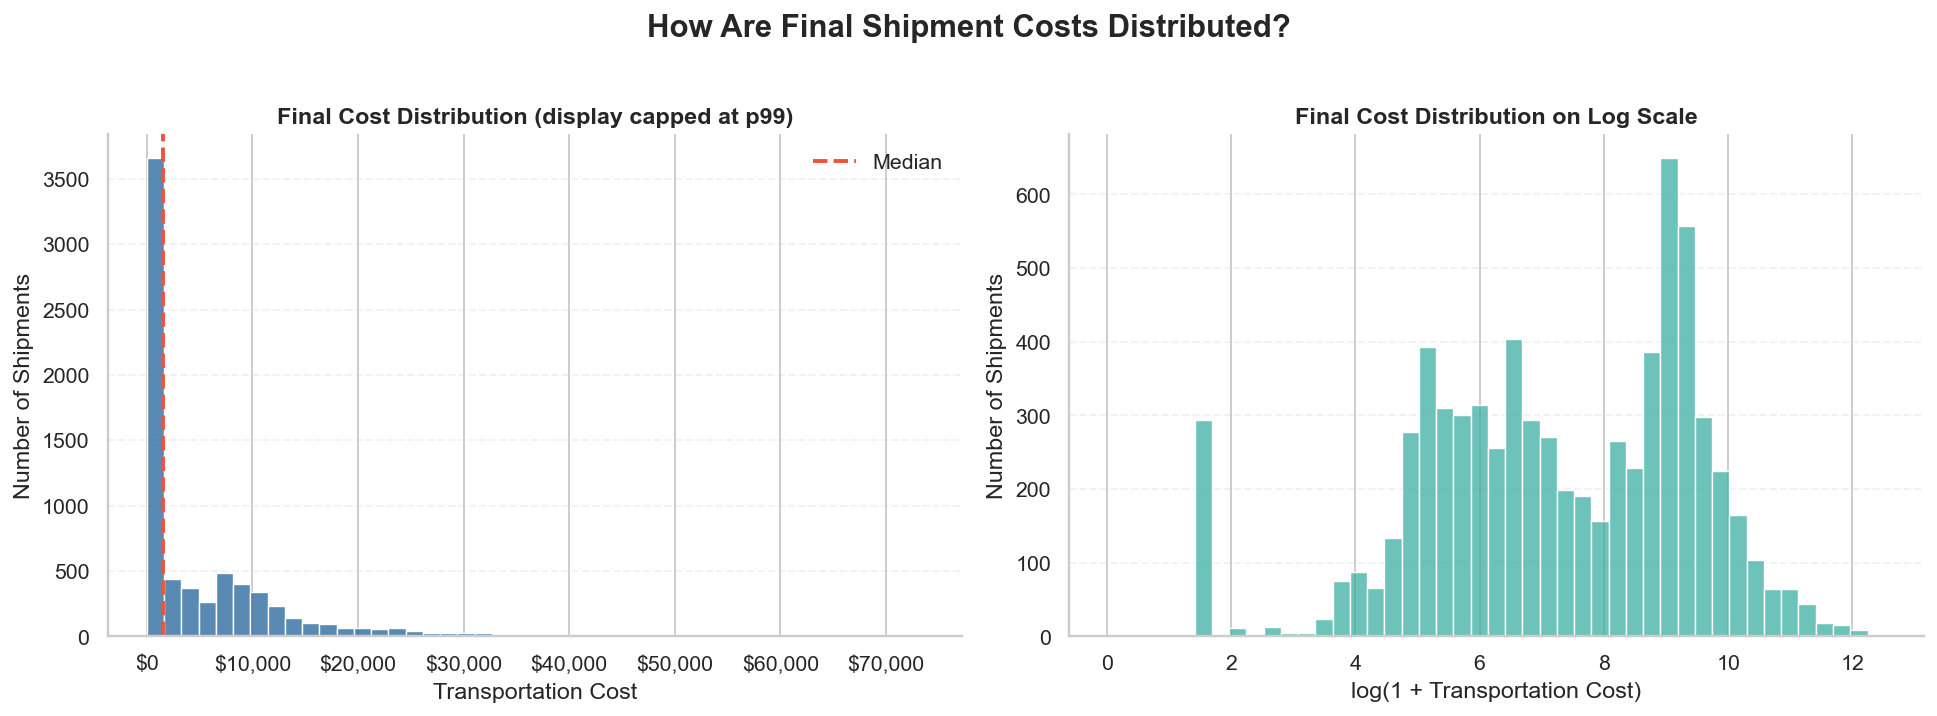

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=140)

display_cap = df["Transportation Cost"].quantile(.99)
sns.histplot(
    df.loc[df["Transportation Cost"] <= display_cap, "Transportation Cost"],
    bins=45, color=COLORS["blue"], edgecolor="white", ax=axes[0]
)
axes[0].axvline(df["Transportation Cost"].median(), color=COLORS["red"], linestyle="--", linewidth=2, label="Median")
axes[0].xaxis.set_major_formatter(currency)
axes[0].set_title("Final Cost Distribution (display capped at p99)", fontweight="bold")
axes[0].set_xlabel("Transportation Cost")
axes[0].set_ylabel("Number of Shipments")
axes[0].legend(frameon=False)
clean_axes(axes[0], "y")

sns.histplot(np.log1p(df["Transportation Cost"]), bins=45, color=COLORS["teal"], edgecolor="white", ax=axes[1])
axes[1].set_title("Final Cost Distribution on Log Scale", fontweight="bold")
axes[1].set_xlabel("log(1 + Transportation Cost)")
axes[1].set_ylabel("Number of Shipments")
clean_axes(axes[1], "y")

fig.suptitle("How Are Final Shipment Costs Distributed?", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [25]:
cost = df["Transportation Cost"]
display(Markdown(f'''
**Numerical analysis.** The cleaned dataset contains **{len(cost):,} completed shipments**. The median final cost is **${cost.median():,.2f}**, while the mean is **${cost.mean():,.2f}**. The mean is **{cost.mean()/cost.median():.1f} times** the median, confirming a strong right-skew caused by expensive shipments. The 90th, 95th, and 99th percentiles are **${cost.quantile(.90):,.2f}**, **${cost.quantile(.95):,.2f}**, and **${cost.quantile(.99):,.2f}**, respectively; the maximum is **${cost.max():,.2f}**. This variability supports producing a quote range rather than relying only on a point estimate.
'''))


**Numerical analysis.** The cleaned dataset contains **7,167 completed shipments**. The median final cost is **$1,495.37**, while the mean is **$7,174.51**. The mean is **4.8 times** the median, confirming a strong right-skew caused by expensive shipments. The 90th, 95th, and 99th percentiles are **$16,897.85**, **$26,889.36**, and **$73,709.43**, respectively; the maximum is **$274,467.21**. This variability supports producing a quote range rather than relying only on a point estimate.


## Visualization 2 — Shipment Mix by Transport Type

**What is being shown?** This chart shows the number and percentage of cleaned shipments associated with each transport type. It identifies where the model has abundant historical examples and where predictions may be less stable because data is sparse.

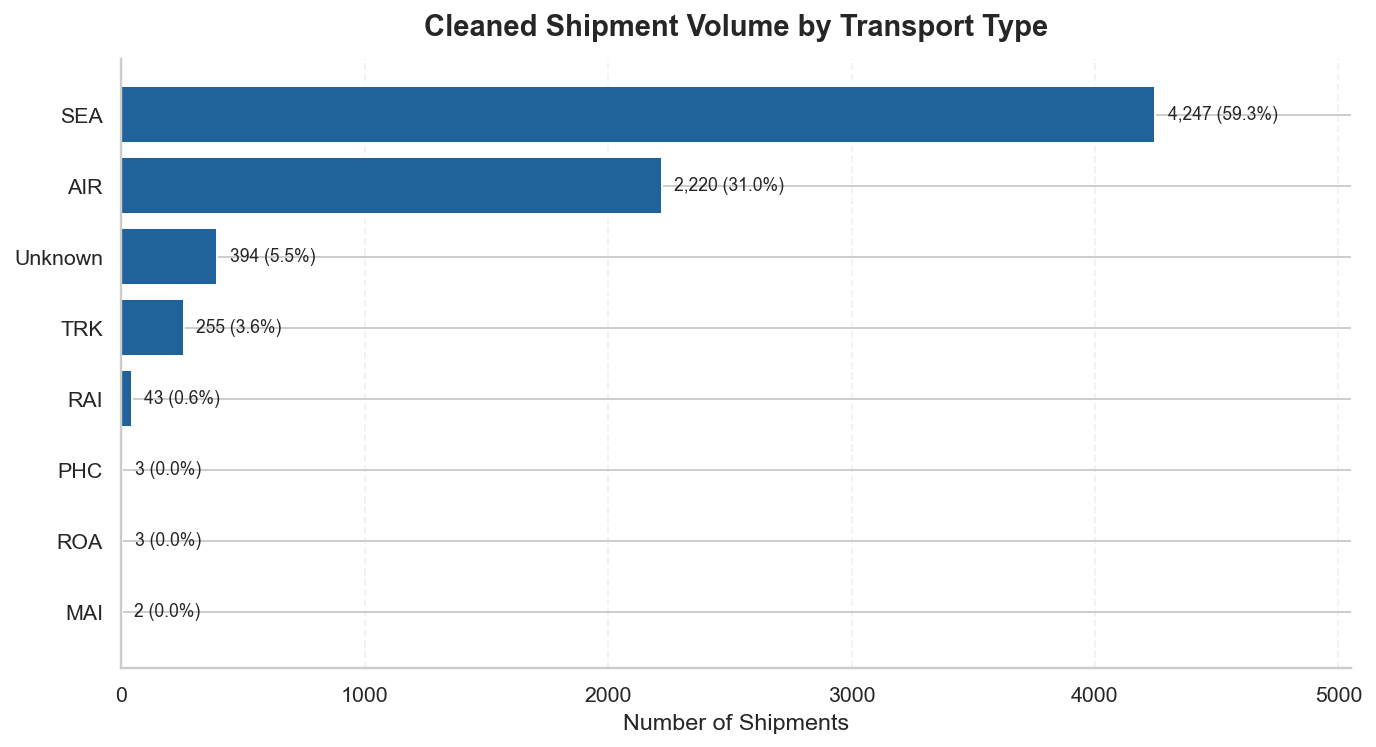

In [26]:
transport_mix = df["Transport Type"].fillna("Unknown").value_counts().to_frame("Shipments")
transport_mix["Share"] = transport_mix["Shipments"] / transport_mix["Shipments"].sum()

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=140)
bars = ax.barh(transport_mix.index[::-1], transport_mix["Shipments"][::-1], color=COLORS["blue"])
for bar, n, share in zip(bars, transport_mix["Shipments"][::-1], transport_mix["Share"][::-1]):
    ax.text(bar.get_width() + transport_mix["Shipments"].max()*.012, bar.get_y()+bar.get_height()/2,
            f"{n:,} ({share:.1%})", va="center", fontsize=9)
ax.set_title("Cleaned Shipment Volume by Transport Type", fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Number of Shipments")
ax.set_ylabel("")
ax.set_xlim(0, transport_mix["Shipments"].max()*1.19)
clean_axes(ax, "x")
plt.tight_layout()
plt.show()

In [27]:
leader = transport_mix.iloc[0]
second = transport_mix.iloc[1] if len(transport_mix) > 1 else pd.Series({"Shipments":0,"Share":0})
display(Markdown(f'''
**Numerical analysis.** **{transport_mix.index[0]}** is the most common transport type with **{int(leader['Shipments']):,} shipments ({leader['Share']:.1%})**. The second largest category, **{transport_mix.index[1]}**, contains **{int(second['Shipments']):,} shipments ({second['Share']:.1%})**. Together, these two categories represent **{leader['Share'] + second['Share']:.1%}** of the cleaned data. Transport types with very small counts should be reported cautiously because their error estimates and prediction ranges will be based on limited historical evidence.
'''))


**Numerical analysis.** **SEA** is the most common transport type with **4,247 shipments (59.3%)**. The second largest category, **AIR**, contains **2,220 shipments (31.0%)**. Together, these two categories represent **90.2%** of the cleaned data. Transport types with very small counts should be reported cautiously because their error estimates and prediction ranges will be based on limited historical evidence.


## Visualization 3 — Typical Cost by Transport Type

**What is being shown?** The bars compare median final cost by transport type. The horizontal lines show the interquartile range (25th–75th percentile), revealing both the typical cost and within-category variability. Categories are ordered by median cost.

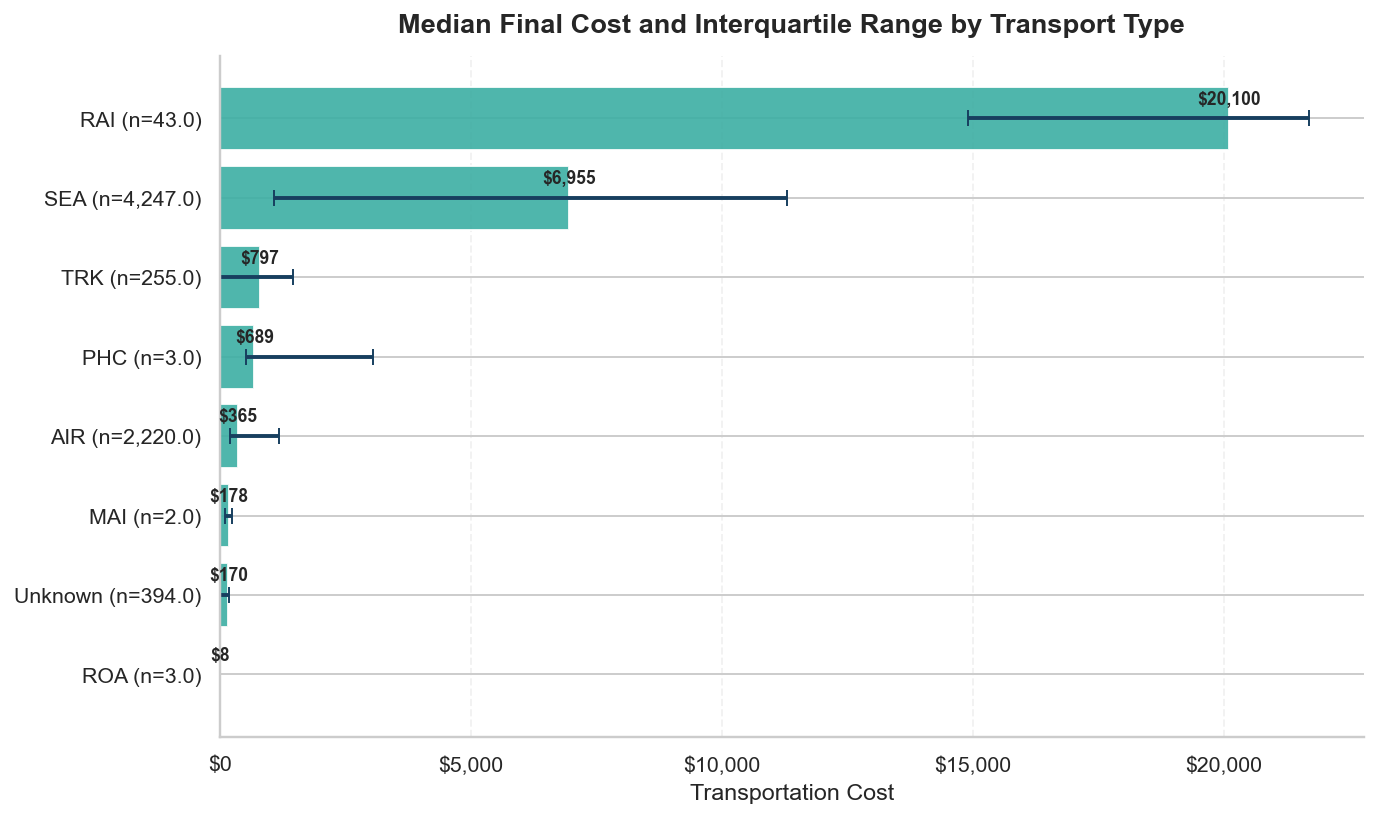

In [28]:
transport_cost = (
    df.groupby("Transport Type", observed=True)["Transportation Cost"]
      .agg(Shipments="size", Median="median", Q1=lambda s:s.quantile(.25),
           Q3=lambda s:s.quantile(.75), P90=lambda s:s.quantile(.90), Mean="mean")
      .sort_values("Median")
)

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)
y = np.arange(len(transport_cost))
ax.barh(y, transport_cost["Median"], color=COLORS["teal"], alpha=.9)
ax.errorbar(
    transport_cost["Median"], y,
    xerr=[transport_cost["Median"]-transport_cost["Q1"], transport_cost["Q3"]-transport_cost["Median"]],
    fmt="none", ecolor=COLORS["navy"], capsize=4, linewidth=2
)
ax.set_yticks(y, [f"{idx} (n={row.Shipments:,})" for idx,row in transport_cost.iterrows()])
for yi, value in zip(y, transport_cost["Median"]):
    ax.text(value, yi+.18, f"${value:,.0f}", ha="center", fontsize=9, fontweight="bold")
ax.xaxis.set_major_formatter(currency)
ax.set_title("Median Final Cost and Interquartile Range by Transport Type", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Transportation Cost")
ax.set_ylabel("")
clean_axes(ax, "x")
plt.tight_layout()
plt.show()

In [29]:
highest = transport_cost.loc[transport_cost["Median"].idxmax()]
lowest = transport_cost.loc[transport_cost["Median"].idxmin()]
display(Markdown(f'''
**Numerical analysis.** **{transport_cost['Median'].idxmax()}** has the highest median cost at **${highest['Median']:,.2f}** across **{int(highest['Shipments']):,} shipments**, with a 90th-percentile cost of **${highest['P90']:,.2f}**. **{transport_cost['Median'].idxmin()}** has the lowest median at **${lowest['Median']:,.2f}** across **{int(lowest['Shipments']):,} shipments**. The highest median is **{highest['Median']/lowest['Median']:.1f} times** the lowest. The visible interquartile ranges show that transport type explains part—but not all—of cost variation, so route and physical shipment characteristics remain necessary.
'''))


**Numerical analysis.** **RAI** has the highest median cost at **$20,100.32** across **43 shipments**, with a 90th-percentile cost of **$26,089.56**. **ROA** has the lowest median at **$8.35** across **3 shipments**. The highest median is **2407.2 times** the lowest. The visible interquartile ranges show that transport type explains part—but not all—of cost variation, so route and physical shipment characteristics remain necessary.


## Visualization 4 — Final Cost by Shipment Mode

**What is being shown?** This chart compares median final cost across modes with at least 30 eligible shipments. The sample-size threshold prevents a rare mode from appearing important because of only a few observations.

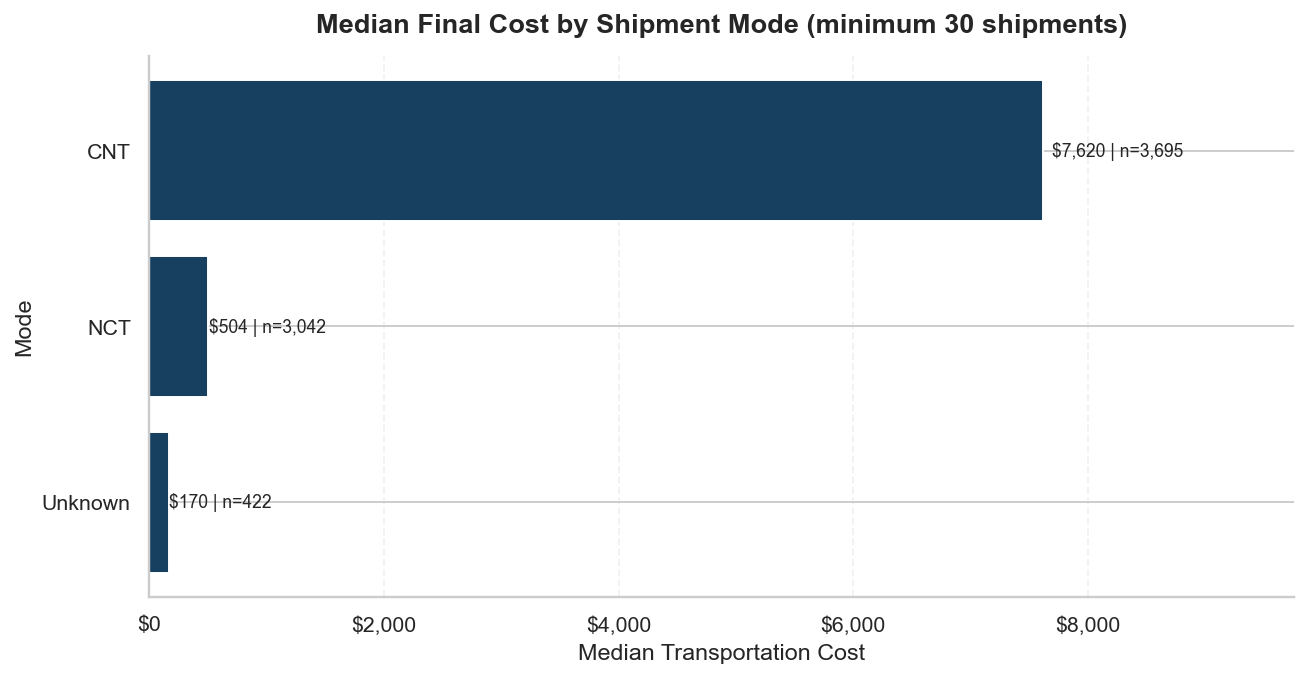

In [30]:
mode_cost = (
    df.groupby("Mode", observed=True)["Transportation Cost"]
      .agg(Shipments="size", Median="median", P90=lambda s:s.quantile(.90))
      .query("Shipments >= 30")
      .sort_values("Median")
)

fig, ax = plt.subplots(figsize=(9.5, 5), dpi=140)
bars = ax.barh(mode_cost.index, mode_cost["Median"], color=COLORS["navy"])
for bar,(idx,row) in zip(bars,mode_cost.iterrows()):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f"${row.Median:,.0f} | n={int(row.Shipments):,}", va="center", fontsize=9)
ax.xaxis.set_major_formatter(currency)
ax.set_title("Median Final Cost by Shipment Mode (minimum 30 shipments)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Median Transportation Cost")
ax.set_ylabel("Mode")
ax.set_xlim(0, mode_cost["Median"].max()*1.28)
clean_axes(ax, "x")
plt.tight_layout()
plt.show()

In [31]:
mode_high = mode_cost.loc[mode_cost["Median"].idxmax()]
mode_low = mode_cost.loc[mode_cost["Median"].idxmin()]
display(Markdown(f'''
**Numerical analysis.** Among modes with at least 30 records, **{mode_cost['Median'].idxmax()}** has the highest median final cost at **${mode_high['Median']:,.2f}** and a p90 of **${mode_high['P90']:,.2f}** from **{int(mode_high['Shipments']):,} shipments**. **{mode_cost['Median'].idxmin()}** has the lowest median at **${mode_low['Median']:,.2f}**. The difference between these medians is **${mode_high['Median']-mode_low['Median']:,.2f}**, demonstrating why mode should be available in the broker’s quoting inputs.
'''))


**Numerical analysis.** Among modes with at least 30 records, **CNT** has the highest median final cost at **$7,620.14** and a p90 of **$22,061.65** from **3,695 shipments**. **Unknown** has the lowest median at **$170.00**. The difference between these medians is **$7,450.14**, demonstrating why mode should be available in the broker’s quoting inputs.


## Visualization 5 — Shipment Volume and Cost by Branch

**What is being shown?** The left panel ranks branches by shipment volume; the right panel compares their median final cost. Viewing both avoids confusing a high-volume branch with a high-cost branch.

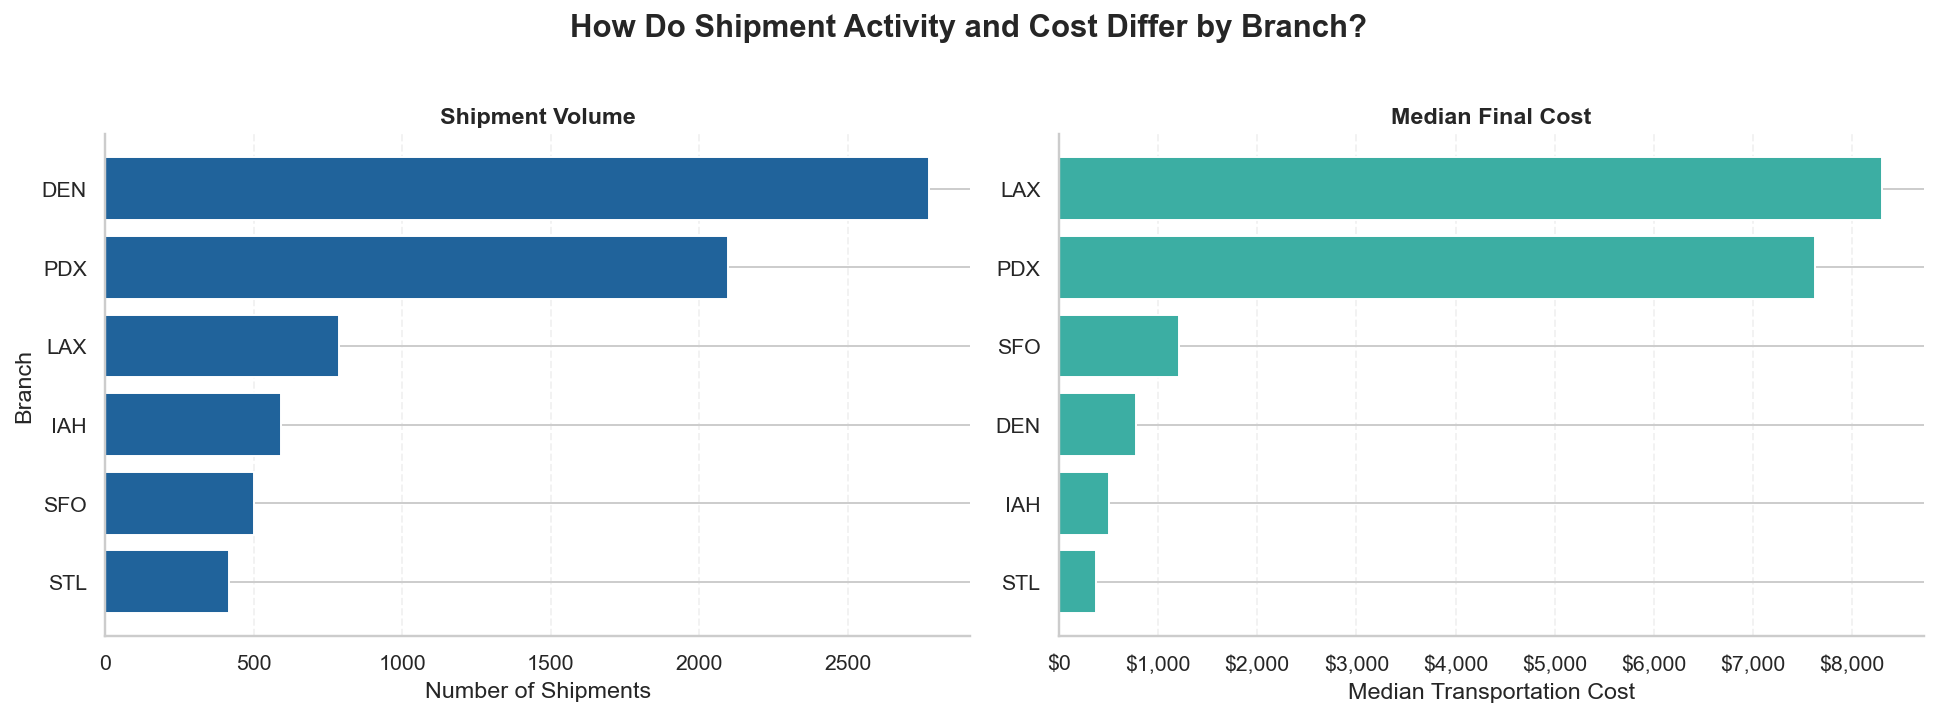

In [32]:
branch_summary = (
    df.groupby("Branch", observed=True)["Transportation Cost"]
      .agg(Shipments="size", Median_Cost="median", P90_Cost=lambda s:s.quantile(.90))
      .sort_values("Shipments", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=140)
order_volume = branch_summary.sort_values("Shipments").index
axes[0].barh(order_volume, branch_summary.loc[order_volume,"Shipments"], color=COLORS["blue"])
axes[0].set_title("Shipment Volume", fontweight="bold")
axes[0].set_xlabel("Number of Shipments"); axes[0].set_ylabel("Branch")
clean_axes(axes[0], "x")

order_cost = branch_summary.sort_values("Median_Cost").index
axes[1].barh(order_cost, branch_summary.loc[order_cost,"Median_Cost"], color=COLORS["teal"])
axes[1].xaxis.set_major_formatter(currency)
axes[1].set_title("Median Final Cost", fontweight="bold")
axes[1].set_xlabel("Median Transportation Cost"); axes[1].set_ylabel("")
clean_axes(axes[1], "x")
fig.suptitle("How Do Shipment Activity and Cost Differ by Branch?", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

In [33]:
busiest = branch_summary.iloc[0]
expensive_branch = branch_summary.loc[branch_summary["Median_Cost"].idxmax()]
total_shipments = branch_summary["Shipments"].sum()
display(Markdown(f'''
**Numerical analysis.** **{branch_summary.index[0]}** is the busiest branch with **{int(busiest['Shipments']):,} shipments ({busiest['Shipments']/total_shipments:.1%} of the cleaned dataset)** and a median cost of **${busiest['Median_Cost']:,.2f}**. The branch with the highest median cost is **{branch_summary['Median_Cost'].idxmax()}** at **${expensive_branch['Median_Cost']:,.2f}**, with a p90 of **${expensive_branch['P90_Cost']:,.2f}** across **{int(expensive_branch['Shipments']):,} shipments**. Branch therefore captures differences beyond simple shipment volume and may represent distinct route or customer mixes.
'''))


**Numerical analysis.** **DEN** is the busiest branch with **2,773 shipments (38.7% of the cleaned dataset)** and a median cost of **$780.45**. The branch with the highest median cost is **LAX** at **$8,305.49**, with a p90 of **$29,398.78** across **788 shipments**. Branch therefore captures differences beyond simple shipment volume and may represent distinct route or customer mixes.


## Visualization 6 — Monthly Shipment Volume and Median Cost

**What is being shown?** Bars show the number of jobs opened each month, while the line shows median final cost. This identifies changes in workload and cost level over the December 2025–June 2026 observation period.

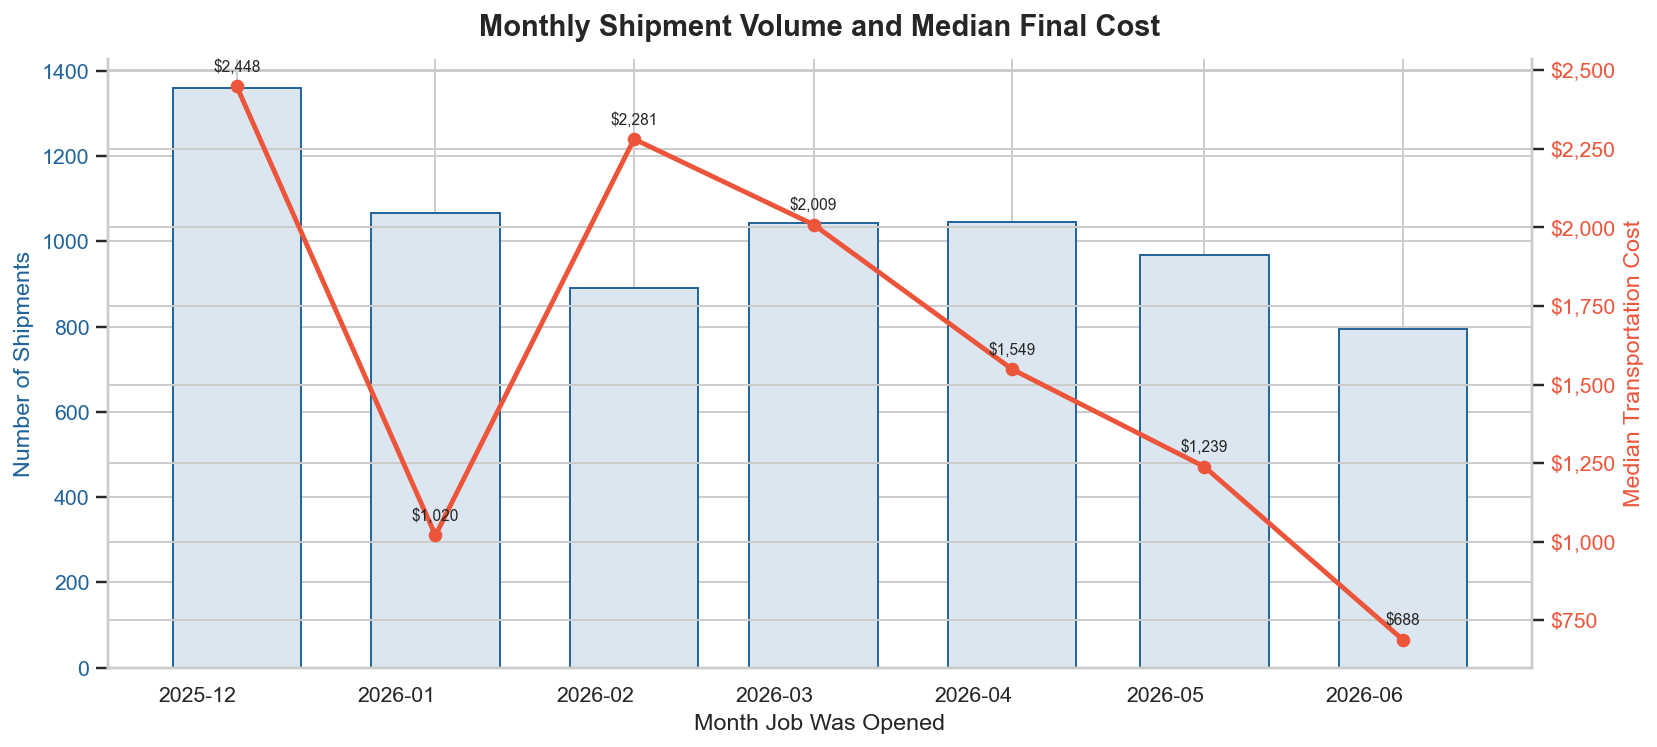

In [34]:
monthly = (
    df.set_index("Job Opened").resample("MS")["Transportation Cost"]
      .agg(Shipments="size", Median_Cost="median", Mean_Cost="mean", P90_Cost=lambda s:s.quantile(.90))
)

fig, ax1 = plt.subplots(figsize=(12, 5.5), dpi=140)
bars = ax1.bar(monthly.index, monthly["Shipments"], width=20, color=COLORS["light"], edgecolor=COLORS["blue"], label="Shipments")
ax1.set_ylabel("Number of Shipments", color=COLORS["blue"])
ax1.set_xlabel("Month Job Was Opened")
ax1.tick_params(axis="y", labelcolor=COLORS["blue"])
ax1.spines["top"].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["Median_Cost"], color=COLORS["red"], marker="o", linewidth=2.5, label="Median cost")
for x,y in zip(monthly.index,monthly["Median_Cost"]):
    ax2.annotate(f"${y:,.0f}",(x,y),textcoords="offset points",xytext=(0,8),ha="center",fontsize=8)
ax2.yaxis.set_major_formatter(currency)
ax2.set_ylabel("Median Transportation Cost", color=COLORS["red"])
ax2.tick_params(axis="y", labelcolor=COLORS["red"])
ax2.spines["top"].set_visible(False)
ax1.set_title("Monthly Shipment Volume and Median Final Cost", fontsize=15, fontweight="bold", pad=12)
fig.autofmt_xdate(rotation=0); plt.tight_layout(); plt.show()

In [35]:
high_month = monthly.loc[monthly["Median_Cost"].idxmax()]
low_month = monthly.loc[monthly["Median_Cost"].idxmin()]
busy_month = monthly.loc[monthly["Shipments"].idxmax()]
display(Markdown(f'''
**Numerical analysis.** The highest monthly median occurs in **{monthly['Median_Cost'].idxmax():%B %Y}** at **${high_month['Median_Cost']:,.2f}** from **{int(high_month['Shipments']):,} shipments**. The lowest occurs in **{monthly['Median_Cost'].idxmin():%B %Y}** at **${low_month['Median_Cost']:,.2f}**, a difference of **${high_month['Median_Cost']-low_month['Median_Cost']:,.2f}**. The busiest month is **{monthly['Shipments'].idxmax():%B %Y}** with **{int(busy_month['Shipments']):,} shipments**. This temporal variation supports evaluating the model on later months rather than using a purely random test split.
'''))


**Numerical analysis.** The highest monthly median occurs in **December 2025** at **$2,448.44** from **1,360 shipments**. The lowest occurs in **June 2026** at **$687.70**, a difference of **$1,760.74**. The busiest month is **December 2025** with **1,360 shipments**. This temporal variation supports evaluating the model on later months rather than using a purely random test split.


## Visualization 7 — Weight and Final Cost

**What is being shown?** The scatterplot compares positive normalized weight with final cost, colored by transport type. Logarithmic axes preserve both small and large shipments in the same chart. Zero-weight shipments remain in the data but cannot appear on a logarithmic x-axis, so they are quantified in the analysis below.

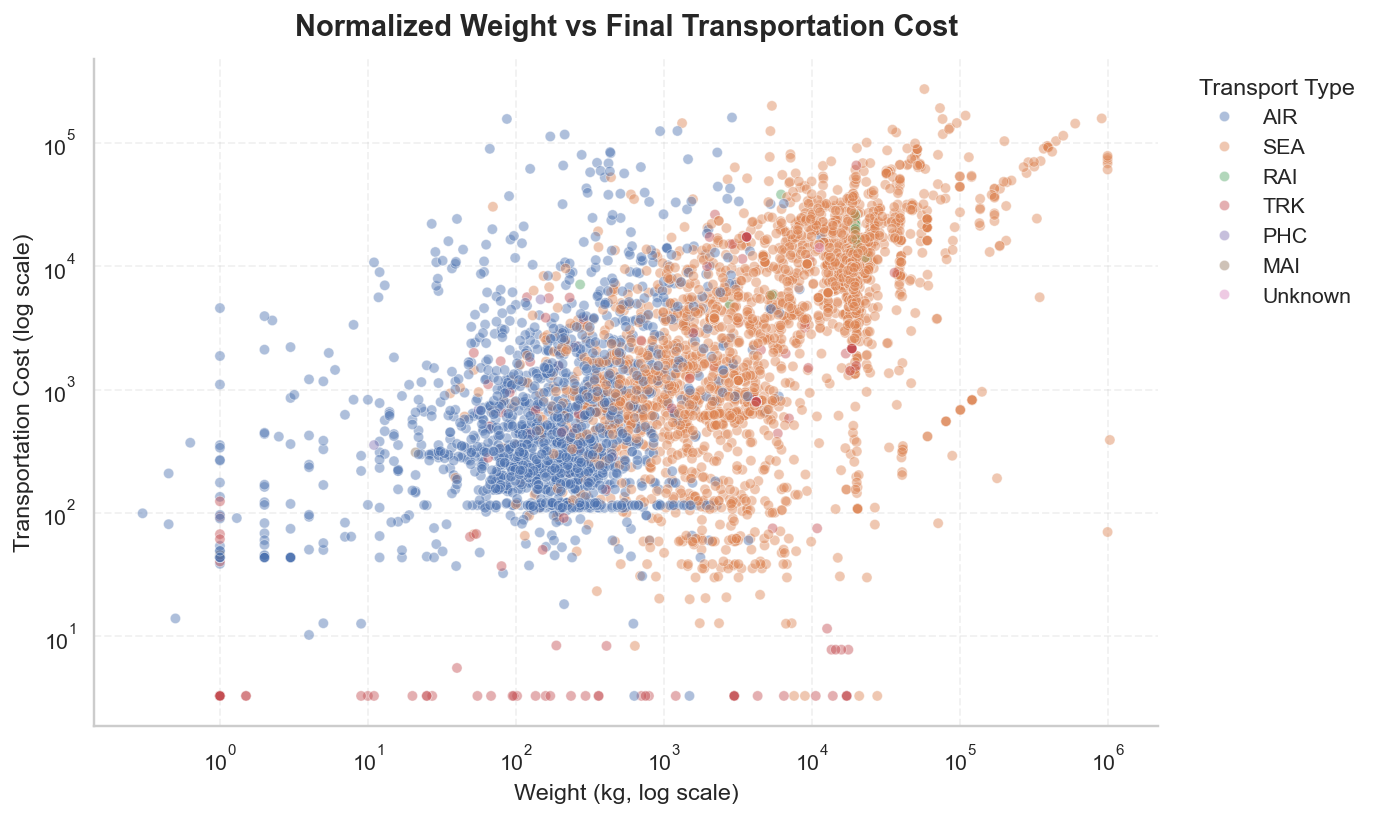

In [36]:
weight_plot = df[(df["Weight kg"] > 0) & (df["Transportation Cost"] > 0)].copy()
if len(weight_plot) > 5000:
    weight_plot = weight_plot.sample(5000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)
sns.scatterplot(data=weight_plot, x="Weight kg", y="Transportation Cost", hue="Transport Type",
                alpha=.45, s=28, palette="deep", ax=ax)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Normalized Weight vs Final Transportation Cost", fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Weight (kg, log scale)"); ax.set_ylabel("Transportation Cost (log scale)")
ax.legend(title="Transport Type", bbox_to_anchor=(1.02,1), loc="upper left", frameon=False)
clean_axes(ax, "both"); plt.tight_layout(); plt.show()

In [37]:
positive_weight = df[df["Weight kg"] > 0]
weight_corr = positive_weight[["Weight kg","Transportation Cost"]].corr(method="spearman").iloc[0,1]
zero_weight_share = df["Weight kg"].eq(0).mean()
segment_corr = (
    positive_weight.groupby("Transport Type", observed=True)
    .apply(lambda g: g[["Weight kg","Transportation Cost"]].corr(method="spearman").iloc[0,1] if len(g)>=30 else np.nan)
    .dropna().sort_values(ascending=False)
)
segment_text = ", ".join(f"{k}: {v:.2f}" for k,v in segment_corr.items())
display(Markdown(f'''
**Numerical analysis.** **{zero_weight_share:.1%}** of eligible shipments have a valid operational weight of zero and remain in the model. Among shipments with positive weight, the overall Spearman correlation between weight and final cost is **{weight_corr:.2f}**. By transport type (minimum 30 observations), the correlations are **{segment_text}**. Differences across transport types show why weight should be interpreted jointly with transport type rather than as a universal price rule.
'''))


**Numerical analysis.** **7.8%** of eligible shipments have a valid operational weight of zero and remain in the model. Among shipments with positive weight, the overall Spearman correlation between weight and final cost is **0.68**. By transport type (minimum 30 observations), the correlations are **SEA: 0.63, TRK: 0.40, AIR: 0.23, RAI: -0.40**. Differences across transport types show why weight should be interpreted jointly with transport type rather than as a universal price rule.


## Visualization 8 — Volume and Final Cost

**What is being shown?** This log-scale scatterplot compares positive normalized volume with final cost by transport type. Structural zero-volume shipments are preserved in the dataset and quantified separately below.

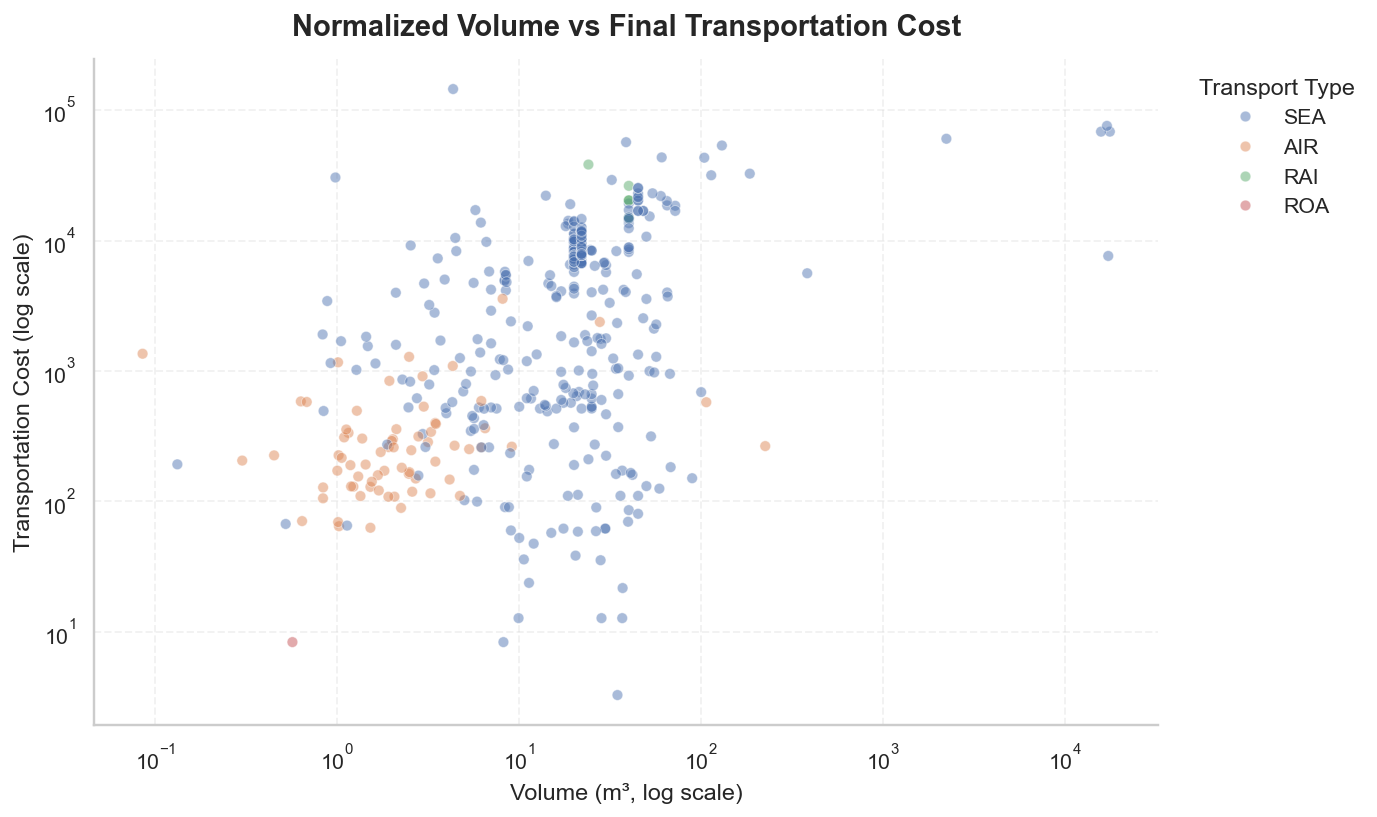

In [38]:
volume_plot = df[(df["Volume m3"] > 0) & (df["Transportation Cost"] > 0)].copy()
if len(volume_plot) > 5000:
    volume_plot = volume_plot.sample(5000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)
sns.scatterplot(data=volume_plot, x="Volume m3", y="Transportation Cost", hue="Transport Type",
                alpha=.48, s=30, palette="deep", ax=ax)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Normalized Volume vs Final Transportation Cost", fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Volume (m³, log scale)"); ax.set_ylabel("Transportation Cost (log scale)")
ax.legend(title="Transport Type", bbox_to_anchor=(1.02,1), loc="upper left", frameon=False)
clean_axes(ax, "both"); plt.tight_layout(); plt.show()

In [39]:
positive_volume = df[df["Volume m3"] > 0]
volume_corr = positive_volume[["Volume m3","Transportation Cost"]].corr(method="spearman").iloc[0,1]
zero_volume = df[df["Volume m3"].eq(0)]["Transportation Cost"]
positive_volume_cost = positive_volume["Transportation Cost"]
display(Markdown(f'''
**Numerical analysis.** **{df['Volume m3'].eq(0).mean():.1%}** of eligible shipments have an operational volume of zero. Among positive-volume shipments, Spearman correlation with final cost is **{volume_corr:.2f}**. The median cost is **${positive_volume_cost.median():,.2f}** when volume is positive versus **${zero_volume.median():,.2f}** when volume is zero. This difference partly reflects transport mode, so volume and transport type should both be supplied to the model.
'''))


**Numerical analysis.** **93.7%** of eligible shipments have an operational volume of zero. Among positive-volume shipments, Spearman correlation with final cost is **0.46**. The median cost is **$2,539.55** when volume is positive versus **$1,453.87** when volume is zero. This difference partly reflects transport mode, so volume and transport type should both be supplied to the model.


## Visualization 9 — Containerization and Final Cost

**What is being shown?** Shipments are divided into containerized (`Container Count > 0`) and non-containerized (`Container Count = 0`) groups. The chart compares their cost distributions up to each group’s 99th percentile for readability.

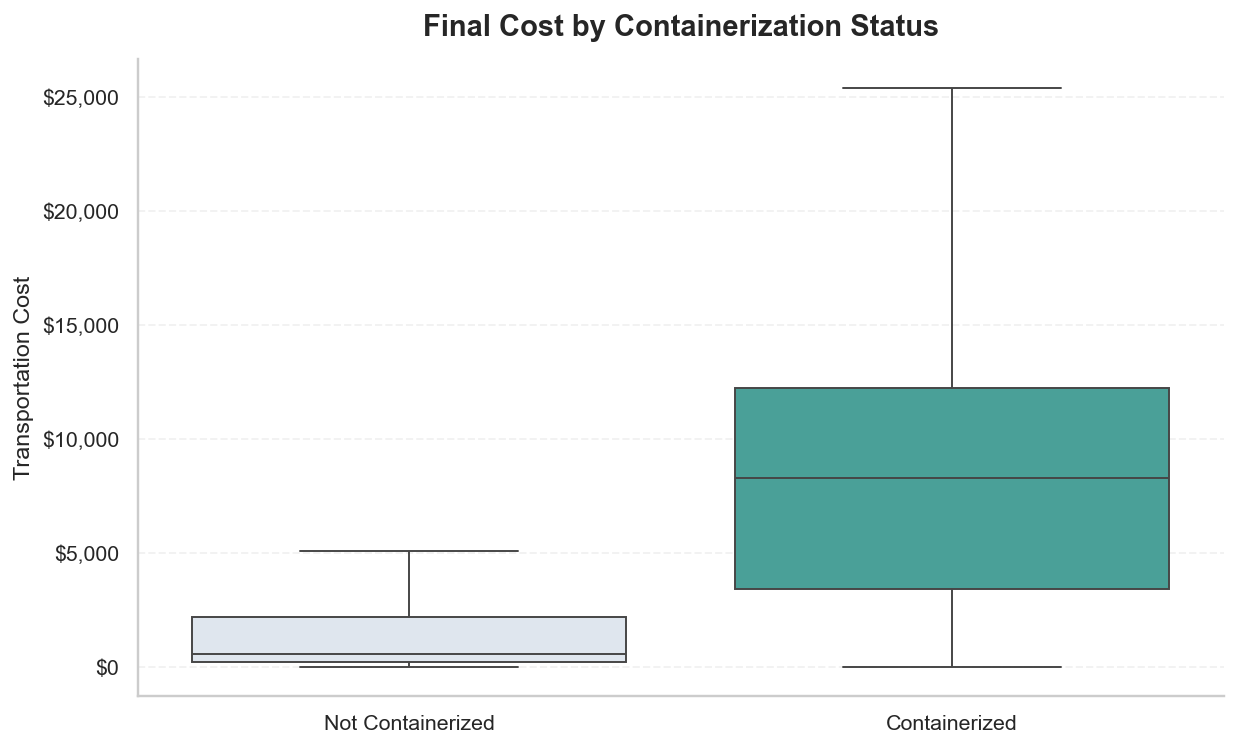

In [40]:
container_df = df.copy()
container_df["Containerization"] = np.where(container_df["Container Count"] > 0, "Containerized", "Not Containerized")
container_cap = container_df.groupby("Containerization")["Transportation Cost"].transform(lambda s:s.quantile(.99))
container_plot = container_df[container_df["Transportation Cost"] <= container_cap]

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=140)
sns.boxplot(data=container_plot, x="Containerization", y="Transportation Cost",
            order=["Not Containerized","Containerized"], palette=[COLORS["light"],COLORS["teal"]], showfliers=False, ax=ax)
ax.yaxis.set_major_formatter(currency)
ax.set_title("Final Cost by Containerization Status", fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel(""); ax.set_ylabel("Transportation Cost")
clean_axes(ax, "y"); plt.tight_layout(); plt.show()

In [41]:
container_summary = (
    container_df.groupby("Containerization")["Transportation Cost"]
    .agg(Shipments="size", Median="median", Mean="mean", P90=lambda s:s.quantile(.90))
)
c = container_summary.loc["Containerized"]
nc = container_summary.loc["Not Containerized"]
display(Markdown(f'''
**Numerical analysis.** The dataset contains **{int(c['Shipments']):,} containerized shipments ({c['Shipments']/len(container_df):.1%})** and **{int(nc['Shipments']):,} non-containerized shipments ({nc['Shipments']/len(container_df):.1%})**. Their median costs are **${c['Median']:,.2f}** and **${nc['Median']:,.2f}**, respectively—a difference of **${c['Median']-nc['Median']:,.2f}**. Their p90 costs are **${c['P90']:,.2f}** and **${nc['P90']:,.2f}**, confirming that container count and TEU can materially help quote estimation.
'''))


**Numerical analysis.** The dataset contains **2,835 containerized shipments (39.6%)** and **4,332 non-containerized shipments (60.4%)**. Their median costs are **$8,296.34** and **$570.45**, respectively—a difference of **$7,725.89**. Their p90 costs are **$22,103.13** and **$9,978.60**, confirming that container count and TEU can materially help quote estimation.


## Visualization 10 — Highest-Cost Established Routes

**What is being shown?** This chart ranks the 12 routes with the highest median final cost among routes with at least 10 completed shipments. Requiring a minimum history makes the comparison more defensible than ranking routes represented by only one or two shipments.

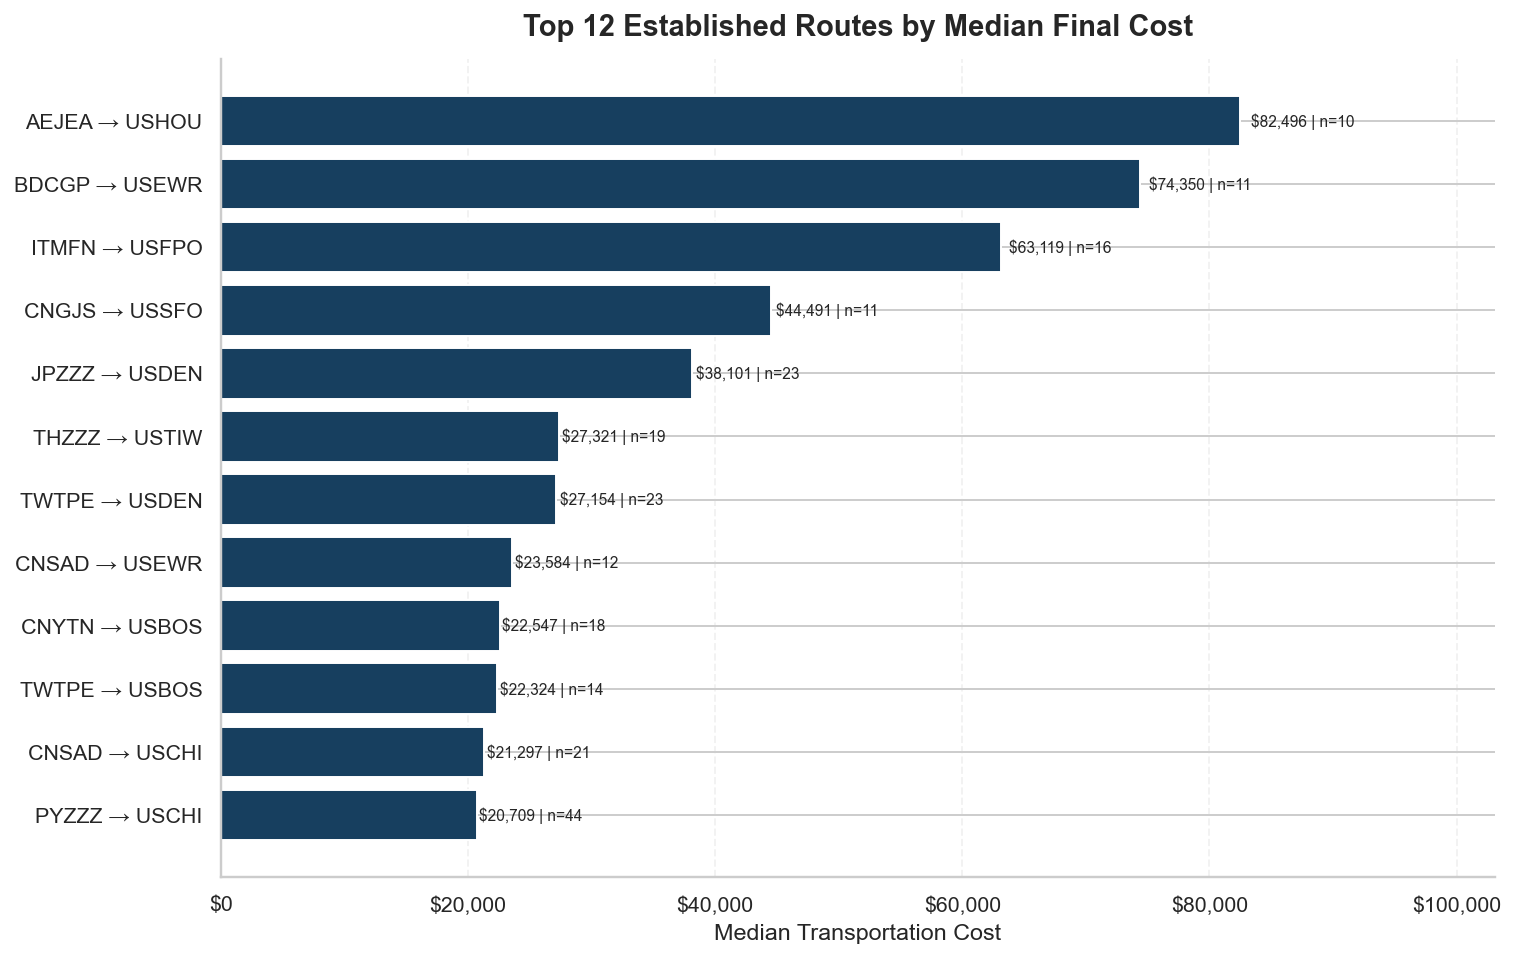

In [42]:
route_summary = (
    df.assign(Route=df["Origin Port"].fillna("Unknown") + " → " + df["Final Destination"].fillna("Unknown"))
      .groupby("Route", observed=True)["Transportation Cost"]
      .agg(Shipments="size", Median_Cost="median", P90_Cost=lambda s:s.quantile(.90), Mean_Cost="mean")
      .query("Shipments >= 10")
      .sort_values("Median_Cost", ascending=False)
)
top_routes = route_summary.head(12).sort_values("Median_Cost")

fig, ax = plt.subplots(figsize=(11, 7), dpi=140)
bars = ax.barh(top_routes.index, top_routes["Median_Cost"], color=COLORS["navy"])
for bar,(route,row) in zip(bars,top_routes.iterrows()):
    ax.text(bar.get_width()*1.01,bar.get_y()+bar.get_height()/2,
            f"${row.Median_Cost:,.0f} | n={int(row.Shipments)}",va="center",fontsize=8)
ax.xaxis.set_major_formatter(currency)
ax.set_title("Top 12 Established Routes by Median Final Cost", fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Median Transportation Cost"); ax.set_ylabel("")
ax.set_xlim(0,top_routes["Median_Cost"].max()*1.25)
clean_axes(ax,"x"); plt.tight_layout(); plt.show()

In [43]:
route_leader = route_summary.iloc[0]
frequent_route = route_summary.loc[route_summary["Shipments"].idxmax()]
display(Markdown(f'''
**Numerical analysis.** Among the **{len(route_summary):,} routes with at least 10 completed shipments**, **{route_summary.index[0]}** has the highest median final cost at **${route_leader['Median_Cost']:,.2f}**, with a p90 of **${route_leader['P90_Cost']:,.2f}** from **{int(route_leader['Shipments']):,} shipments**. The most frequently observed established route is **{route_summary['Shipments'].idxmax()}** with **{int(frequent_route['Shipments']):,} shipments** and a median cost of **${frequent_route['Median_Cost']:,.2f}**. Route history is therefore useful, but unseen and low-frequency routes will require the model to generalize from origin, destination, transport type, and physical characteristics.
'''))


**Numerical analysis.** Among the **121 routes with at least 10 completed shipments**, **AEJEA → USHOU** has the highest median final cost at **$82,495.86**, with a p90 of **$96,224.70** from **10 shipments**. The most frequently observed established route is **Unknown → Unknown** with **318 shipments** and a median cost of **$173.28**. Route history is therefore useful, but unseen and low-frequency routes will require the model to generalize from origin, destination, transport type, and physical characteristics.


## EDA Conclusion

The ten analyses above establish whether transportation type, mode, branch, time, physical dimensions, containerization, and route history contain useful information for estimating final cost. The next section converts these business relationships into quote-time features while ensuring that actual post-shipment financial and operational outcomes are excluded.

# 4. Feature Engineering

Only quote-time fields are used. All learned preprocessing remains inside the pipeline to prevent leakage.

In [44]:
model_df = df.copy()

model_df["Route"] = (
    model_df["Origin Port"].fillna("Unknown") + " → " +
    model_df["Final Destination"].fillna("Unknown")
)
model_df["Quote Month"] = model_df["Job Opened"].dt.month.astype("Int64")
model_df["Quote Quarter"] = model_df["Job Opened"].dt.quarter.astype("Int64")
model_df["Quote Weekday"] = model_df["Job Opened"].dt.dayofweek.astype("Int64")

numeric_features = [
    "Standalone", "Invoice Headers", "Invoice Lines", "Weight kg", "Volume m3",
    "Packs", "Container Count", "TEU", "Quote Month", "Quote Quarter",
    "Quote Weekday"
]
categorical_features = [
    "Transport Type", "Declaration Type", "Mode", "Branch",
    "Origin Port", "Final Destination", "Load Port", "Arrival Port",
    "Package Type", "Route"
]

# Keep the categorical preprocessing matrix homogeneous: strings plus np.nan only.
# Standalone is a 0/1 binary variable and therefore belongs in numeric_features.
for col in categorical_features:
    model_df[col] = model_df[col].astype("object").where(model_df[col].notna(), np.nan)

features = numeric_features + categorical_features
target = "Transportation Cost"

leakage_excluded = [
    "Declaration ID", "Cost", "Revenue", "WIP", "Accrual", "Total Income",
    "Total Expense", "Job Profit", "Origin ETD", "Dest. ETA", "Load ATD",
    "Arrival ATA", "Status", "Dec. Registered", "Job Operator",
    "Supplier", "Supplier Name", "Importer", "Importer Name",
    "Local Client", "Local Client Name"
]

print("Features used:", len(features))
print("Explicitly excluded leakage/high-cardinality fields:", len(leakage_excluded))
assert not set(features).intersection(leakage_excluded)

Features used: 21
Explicitly excluded leakage/high-cardinality fields: 21


In [45]:
# Chronological partitions: 60% train, 15% validation, 10% calibration, 15% final test.
model_df = model_df.sort_values("Job Opened").reset_index(drop=True)
n = len(model_df)
i_train = int(n * .60)
i_valid = int(n * .75)
i_cal = int(n * .85)

parts = {
    "train": model_df.iloc[:i_train],
    "validation": model_df.iloc[i_train:i_valid],
    "calibration": model_df.iloc[i_valid:i_cal],
    "test": model_df.iloc[i_cal:],
}

split_summary = pd.DataFrame({
    name: {"rows": len(part), "start": part["Job Opened"].min(), "end": part["Job Opened"].max()}
    for name, part in parts.items()
}).T
display(split_summary)

X_train, y_train = parts["train"][features], parts["train"][target]
X_valid, y_valid = parts["validation"][features], parts["validation"][target]
X_cal, y_cal = parts["calibration"][features], parts["calibration"][target]
X_test, y_test = parts["test"][features], parts["test"][target]

,rows,start,end
train,4300,2025-12-01 14:45:00,2026-03-30 20:17:00
validation,1075,2026-03-30 20:19:00,2026-04-30 16:55:00
calibration,716,2026-04-30 16:56:00,2026-05-21 16:55:00
test,1076,2026-05-21 17:04:00,2026-06-30 23:18:00


In [46]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10))
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipe, numeric_features),
    ("categorical", categorical_pipe, categorical_features)
])

def log_target_model(estimator):
    pipe = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

# 5. Modeling — Baseline and Candidate Comparison

Four approaches are evaluated to determine whether the available quote-time features improve cost estimation beyond a simple rule:

- **Baseline (median):** predicts the training median for every shipment. It is the minimum benchmark; a useful model must produce a lower validation error.
- **Ridge Regression:** tests whether cost can be represented by a regularized linear combination of shipment characteristics. It provides a simpler reference and handles the many one-hot encoded categories more safely than ordinary linear regression.
- **Random Forest:** captures nonlinear relationships and interactions—for example, the effect of weight may differ between AIR and SEA or between routes—without requiring those interactions to be specified manually.
- **Extra Trees:** provides a second tree-based strategy with more randomized splits. Comparing it with Random Forest shows whether additional randomization improves generalization or merely adds instability.

All candidates use the same preprocessing and chronological train/validation partitions. Models are compared primarily using **validation MAE**, because it expresses the average absolute quote error directly in cost units. **Lower MAE is better.** RMSE, median absolute error, and R² are retained as supporting metrics.

In [47]:
models = {
    "Baseline (median)": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="median"))
    ]),
    "Ridge": log_target_model(Ridge(alpha=10.0)),
    "Random Forest": log_target_model(RandomForestRegressor(
        n_estimators=350, min_samples_leaf=3, max_features=.7,
        random_state=RANDOM_STATE, n_jobs=-1
    )),
    "Extra Trees": log_target_model(ExtraTreesRegressor(
        n_estimators=350, min_samples_leaf=2, max_features=.8,
        random_state=RANDOM_STATE, n_jobs=-1
    )),
}

def regression_metrics(y_true, prediction):
    prediction = np.maximum(prediction, 0)
    return {
        "MAE": mean_absolute_error(y_true, prediction),
        "RMSE": mean_squared_error(y_true, prediction, squared=False),
        "R2": r2_score(y_true, prediction),
        "Median AE": np.median(np.abs(np.asarray(y_true) - prediction)),
    }

fitted_models = {}
rows = []
for name, model in models.items():
    fitted = clone(model).fit(X_train, y_train)
    pred = fitted.predict(X_valid)
    fitted_models[name] = fitted
    rows.append({"Model": name, **regression_metrics(y_valid, pred)})

validation_results = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
display(validation_results.style.format({"MAE":"${:,.0f}", "RMSE":"${:,.0f}", "Median AE":"${:,.0f}", "R2":"{:.3f}"}))

,Model,MAE,RMSE,R2,Median AE
0,Extra Trees,"$3,337","$9,878",0.484,$538
1,Random Forest,"$3,339","$10,555",0.410,$540
2,Ridge,"$4,453","$14,307",-0.083,$900
3,Baseline (median),"$6,213","$14,586",-0.126,"$1,764"


## Initial Model Comparison — Chronological Validation MAE

**What is being shown?** The chart compares the average absolute prediction error on the validation period. The baseline is shown in gray, while the three candidate models are shown in blue. The best initial candidate is highlighted in teal. Each label reports the exact MAE and its percentage improvement relative to the baseline. A shorter bar indicates a more accurate model.

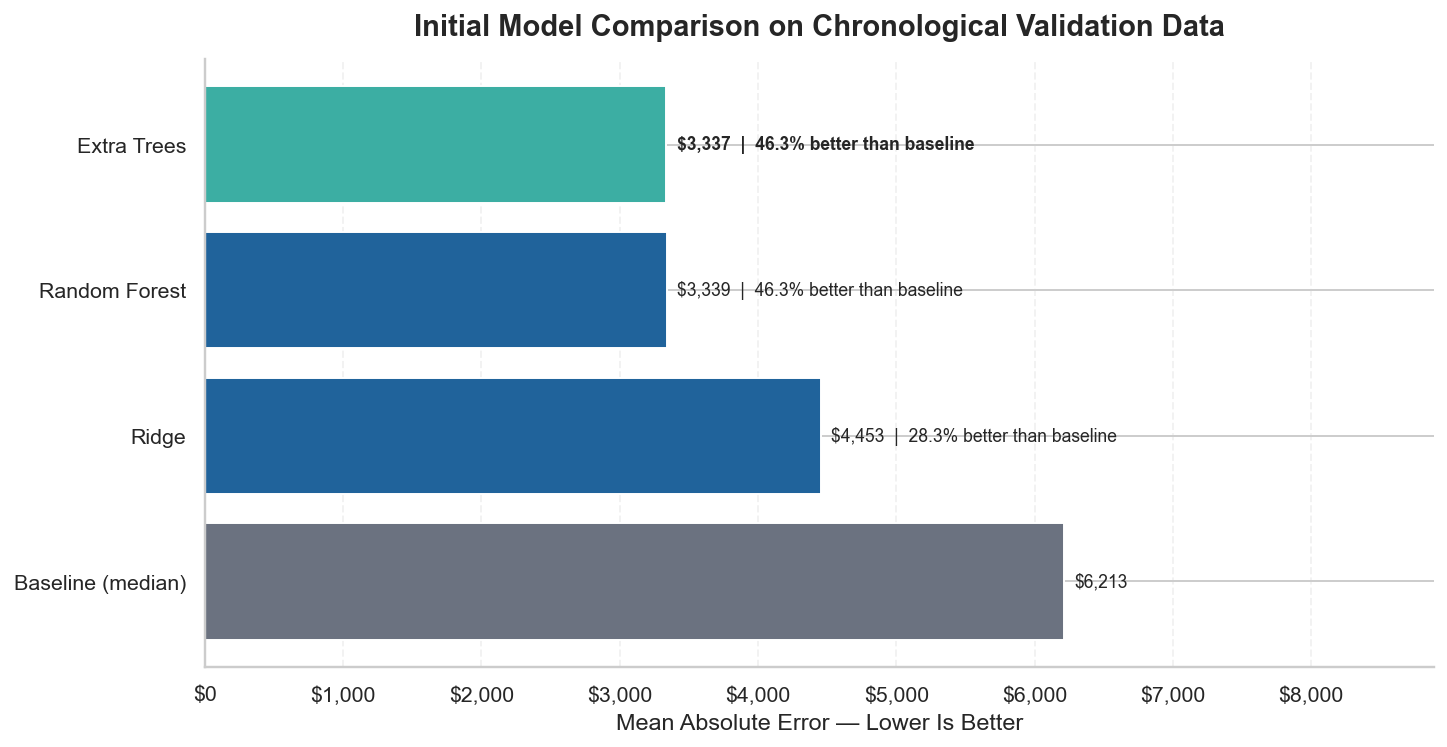

In [48]:
comparison_plot = validation_results.copy().sort_values("MAE", ascending=False)
baseline_mae = float(
    comparison_plot.loc[comparison_plot["Model"] == "Baseline (median)", "MAE"].iloc[0]
)
candidate_mask = comparison_plot["Model"] != "Baseline (median)"
initial_winner = comparison_plot.loc[candidate_mask].sort_values("MAE").iloc[0]["Model"]

colors = [
    COLORS["gray"] if model == "Baseline (median)"
    else COLORS["teal"] if model == initial_winner
    else COLORS["blue"]
    for model in comparison_plot["Model"]
]

fig, ax = plt.subplots(figsize=(10.5, 5.5), dpi=140)
bars = ax.barh(comparison_plot["Model"], comparison_plot["MAE"], color=colors)

for bar, (_, row) in zip(bars, comparison_plot.iterrows()):
    improvement = (baseline_mae - row["MAE"]) / baseline_mae
    label = f"${row['MAE']:,.0f}"
    if row["Model"] != "Baseline (median)":
        label += f"  |  {improvement:.1%} better than baseline"
    ax.text(
        bar.get_width() + baseline_mae * .012,
        bar.get_y() + bar.get_height()/2,
        label, va="center", fontsize=9,
        fontweight="bold" if row["Model"] == initial_winner else "normal"
    )

ax.xaxis.set_major_formatter(currency)
ax.set_xlim(0, baseline_mae * 1.43)
ax.set_title("Initial Model Comparison on Chronological Validation Data", fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Mean Absolute Error — Lower Is Better")
ax.set_ylabel("")
clean_axes(ax, "x")
plt.tight_layout()
plt.show()

In [49]:
ranked_candidates = (
    validation_results[validation_results["Model"] != "Baseline (median)"]
    .sort_values("MAE").reset_index(drop=True)
)
winner = ranked_candidates.iloc[0]
runner_up = ranked_candidates.iloc[1]
winner_improvement = (baseline_mae - winner["MAE"]) / baseline_mae
winner_gap = runner_up["MAE"] - winner["MAE"]

display(Markdown(f'''
**Model-comparison analysis.** The baseline produces a validation MAE of **${baseline_mae:,.2f}**. All three candidate models are evaluated against that reference. **{winner['Model']} is the best initial candidate**, with an MAE of **${winner['MAE']:,.2f}**, reducing average absolute error by **${baseline_mae-winner['MAE']:,.2f} ({winner_improvement:.1%})** relative to the baseline. The second-best candidate is **{runner_up['Model']}** at **${runner_up['MAE']:,.2f}**; the difference between the two leading models is **${winner_gap:,.2f} per shipment**.

Therefore, **{winner['Model']} is selected for fine-tuning**, not yet declared the final model. Fine-tuning will test whether its advantage remains under time-series cross-validation. The final decision will be based on performance on the untouched chronological test set after tuning.
'''))


**Model-comparison analysis.** The baseline produces a validation MAE of **$6,213.24**. All three candidate models are evaluated against that reference. **Extra Trees is the best initial candidate**, with an MAE of **$3,336.63**, reducing average absolute error by **$2,876.61 (46.3%)** relative to the baseline. The second-best candidate is **Random Forest** at **$3,338.54**; the difference between the two leading models is **$1.92 per shipment**.

Therefore, **Extra Trees is selected for fine-tuning**, not yet declared the final model. Fine-tuning will test whether its advantage remains under time-series cross-validation. The final decision will be based on performance on the untouched chronological test set after tuning.


# 6. Fine-Tuning the Best Initial Candidate

The candidate with the lowest chronological validation MAE is selected automatically for fine-tuning. The baseline cannot be selected because it is only a reference. `TimeSeriesSplit` preserves temporal order while the search compares parameter combinations using MAE. Training and validation data are combined for this search, while calibration and final test data remain untouched.

Fine-tuning does not guarantee improvement. Its purpose is to determine whether a better parameter configuration generalizes consistently across successive time periods.

In [50]:
candidate_names = ["Ridge", "Random Forest", "Extra Trees"]
best_candidate_name = (
    validation_results[validation_results["Model"].isin(candidate_names)]
    .sort_values("MAE").iloc[0]["Model"]
)
print("Candidate selected for tuning:", best_candidate_name)

X_tune = pd.concat([X_train, X_valid])
y_tune = pd.concat([y_train, y_valid])
tscv = TimeSeriesSplit(n_splits=4)

search_spaces = {
    "Ridge": {"regressor__model__alpha": np.logspace(-2, 3, 40)},
    "Random Forest": {
        "regressor__model__n_estimators": [250, 400, 600],
        "regressor__model__max_depth": [None, 12, 20, 30],
        "regressor__model__min_samples_leaf": [1, 2, 4, 8],
        "regressor__model__max_features": ["sqrt", .5, .8, 1.0],
    },
    "Extra Trees": {
        "regressor__model__n_estimators": [250, 400, 600],
        "regressor__model__max_depth": [None, 12, 20, 30],
        "regressor__model__min_samples_leaf": [1, 2, 4, 8],
        "regressor__model__max_features": ["sqrt", .5, .8, 1.0],
    },
}

search = RandomizedSearchCV(
    estimator=clone(models[best_candidate_name]),
    param_distributions=search_spaces[best_candidate_name],
    n_iter=20 if best_candidate_name != "Ridge" else 30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_tune, y_tune)
print("Best time-series CV MAE:", f"${-search.best_score_:,.0f}")
print("Best parameters:", search.best_params_)
best_model = search.best_estimator_

Candidate selected for tuning: Extra Trees
Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best time-series CV MAE: $3,631
Best parameters: {'regressor__model__n_estimators': 400, 'regressor__model__min_samples_leaf': 2, 'regressor__model__max_features': 0.5, 'regressor__model__max_depth': None}


# 7. Pick the Final Model

The calibration set remains untouched during model choice. The final test is used once for an honest estimate of future performance.

In [51]:
test_prediction = np.maximum(best_model.predict(X_test), 0)
test_metrics = pd.DataFrame(
    [regression_metrics(y_test, test_prediction)],
    index=[best_candidate_name + " (tuned)"]
)
display(test_metrics.style.format({
    "MAE":"${:,.2f}", "RMSE":"${:,.2f}",
    "Median AE":"${:,.2f}", "R2":"{:.3f}"
}))

,MAE,RMSE,R2,Median AE
Extra Trees (tuned),"$3,279.55","$11,551.79",0.425,$534.79


## Final Test — Actual Cost vs Predicted Cost

**What is being shown?** Each point represents a shipment in the untouched final chronological test period. The horizontal position is the actual final cost and the vertical position is the model prediction. The dashed 45-degree line represents perfect predictions; points farther from the line have larger errors. The display is capped at the 99th percentile so the main pattern remains visible, but all test records are included in the metrics.

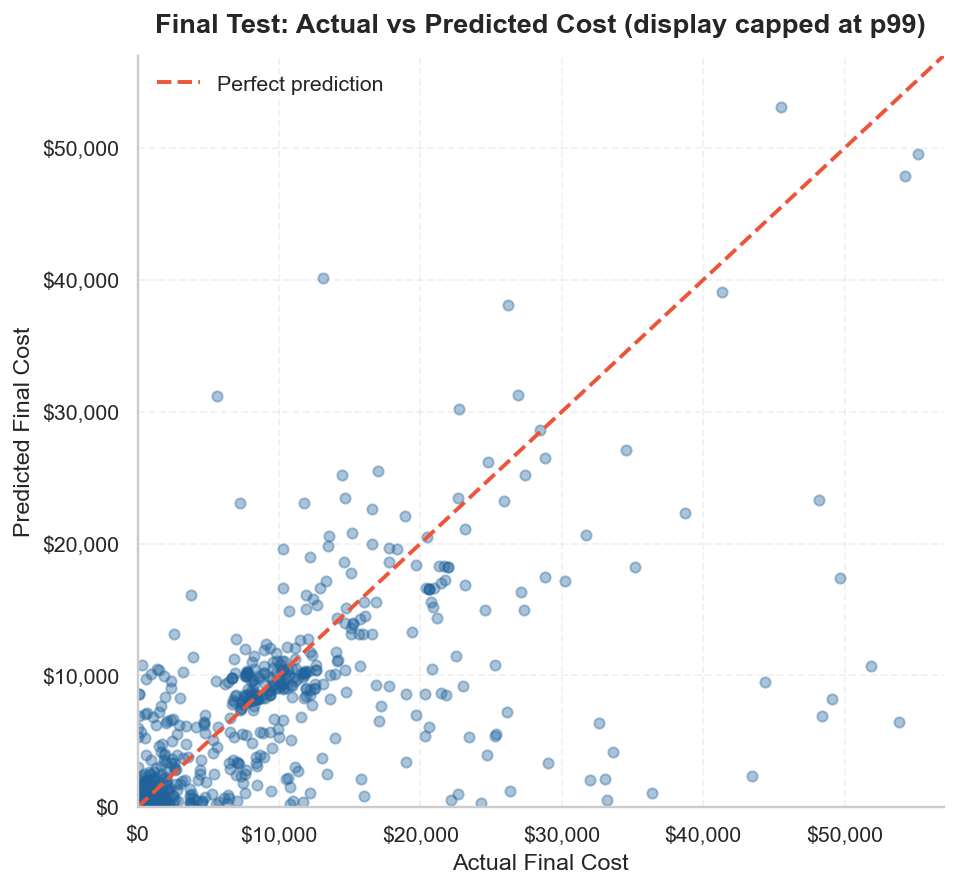

In [52]:
result_plot = pd.DataFrame({"Actual": y_test, "Predicted": test_prediction})
limit = np.quantile(np.r_[result_plot["Actual"], result_plot["Predicted"]], .99)
fig, ax = plt.subplots(figsize=(7, 6.5), dpi=140)
ax.scatter(result_plot["Actual"], result_plot["Predicted"], alpha=.38, s=28, color=COLORS["blue"])
ax.plot([0, limit], [0, limit], "--", color=COLORS["red"], linewidth=2, label="Perfect prediction")
ax.set_xlim(0, limit); ax.set_ylim(0, limit)
ax.xaxis.set_major_formatter(currency); ax.yaxis.set_major_formatter(currency)
ax.set_title("Final Test: Actual vs Predicted Cost (display capped at p99)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Actual Final Cost"); ax.set_ylabel("Predicted Final Cost")
ax.legend(frameon=False)
clean_axes(ax, "both")
plt.tight_layout(); plt.show()

In [53]:
final_mae = test_metrics.iloc[0]["MAE"]
final_rmse = test_metrics.iloc[0]["RMSE"]
final_median_ae = test_metrics.iloc[0]["Median AE"]
final_r2 = test_metrics.iloc[0]["R2"]
within_20pct = np.mean(
    np.abs(y_test.to_numpy() - test_prediction) <= .20 * y_test.to_numpy()
)

display(Markdown(f'''
**Final-test analysis.** The tuned **{best_candidate_name}** achieves an MAE of **${final_mae:,.2f}**, meaning its predictions differ from actual final cost by **${final_mae:,.2f} on average** during the future holdout period. RMSE is **${final_rmse:,.2f}** and median absolute error is **${final_median_ae:,.2f}**. The R² is **{final_r2:.3f}**, and **{within_20pct:.1%}** of test predictions fall within 20% of actual cost. This result—not the initial validation chart—is the final evidence used to assess the selected point-prediction model before constructing quote ranges.
'''))


**Final-test analysis.** The tuned **Extra Trees** achieves an MAE of **$3,279.55**, meaning its predictions differ from actual final cost by **$3,279.55 on average** during the future holdout period. RMSE is **$11,551.79** and median absolute error is **$534.79**. The R² is **0.425**, and **23.4%** of test predictions fall within 20% of actual cost. This result—not the initial validation chart—is the final evidence used to assess the selected point-prediction model before constructing quote ranges.


## Final Model Decision — Tuned Extra Trees

**Extra Trees was selected as the final point-prediction model.** It achieved the lowest MAE during the initial chronological validation comparison and therefore advanced to fine-tuning. The randomized search evaluated **20 hyperparameter combinations across four time-series folds**, resulting in **80 model fits**. The best average time-series cross-validation MAE was **$3,631**.

The selected configuration was:

```python
ExtraTreesRegressor(
    n_estimators=400,
    min_samples_leaf=2,
    max_features=0.5,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
```

When evaluated once on the untouched chronological test period, the tuned model produced:

| Final test metric | Result | Interpretation |
|---|---:|---|
| MAE | **$3,279.55** | Predictions differ from final cost by approximately $3,280 on average. |
| Median Absolute Error | **$534.79** | Half of the test shipments have an absolute error of approximately $535 or less. |
| RMSE | **$11,551.79** | Large errors on a smaller number of unusually expensive or difficult shipments substantially increase the squared-error metric. |
| R² | **0.425** | The model explains approximately 42.5% of the cost variation in the future test period. |

The large difference between the **median absolute error ($534.79)** and the **MAE ($3,279.55)** shows that the model is considerably more accurate for a typical shipment than the overall average error suggests. However, the substantially higher **RMSE ($11,551.79)** confirms that some expensive or uncommon shipments still generate very large errors.

Therefore, the model should be used as a **decision-support tool for freight brokers**, not as a guaranteed final price. Extra Trees provides the best point estimate among the candidates evaluated, but the remaining cost variability makes it necessary to communicate an estimated **cost range**. The next section uses calibration data to convert the point estimate into a prediction interval for customer-quote support.

# 8. Prediction Intervals for Broker Quotes

A split-conformal interval converts the point prediction into a range. With `COVERAGE = 0.90`, the target is approximately 90% marginal coverage on future shipments under comparable conditions.

In [54]:
COVERAGE = 0.90
alpha = 1 - COVERAGE

cal_prediction = np.maximum(best_model.predict(X_cal), 0)
calibration_errors = np.abs(y_cal.to_numpy() - cal_prediction)

# Finite-sample conformal quantile using the 'higher' method.
n_cal = len(calibration_errors)
q_level = min(1.0, np.ceil((n_cal + 1) * (1 - alpha)) / n_cal)
conformal_margin = np.quantile(calibration_errors, q_level, method="higher")

test_lower = np.maximum(0, test_prediction - conformal_margin)
test_upper = test_prediction + conformal_margin
empirical_coverage = np.mean((y_test.to_numpy() >= test_lower) & (y_test.to_numpy() <= test_upper))
average_width = np.mean(test_upper - test_lower)

interval_summary = pd.Series({
    "Requested coverage": COVERAGE,
    "Observed test coverage": empirical_coverage,
    "Conformal margin": conformal_margin,
    "Average interval width": average_width,
})
display(interval_summary)

Requested coverage           0.900000
Observed test coverage       0.893123
Conformal margin          6439.382460
Average interval width    8972.647431
dtype: float64

In [55]:
quote_results = parts["test"][["Job Opened", "Transport Type", "Origin Port", "Final Destination"]].copy()
quote_results["Actual Cost"] = y_test.to_numpy()
quote_results["Point Estimate"] = test_prediction
quote_results["Quote Range Low"] = test_lower
quote_results["Quote Range High"] = test_upper
display(quote_results.head(20).style.format({
    "Actual Cost":"${:,.0f}", "Point Estimate":"${:,.0f}",
    "Quote Range Low":"${:,.0f}", "Quote Range High":"${:,.0f}"
}))

,Job Opened,Transport Type,Origin Port,Final Destination,Actual Cost,Point Estimate,Quote Range Low,Quote Range High
6091,2026-05-21 17:04:00,AIR,Unknown,USTWL,$795,$131,$0,"$6,571"
6092,2026-05-21 17:26:00,AIR,LTVNO,USPHL,$228,$307,$0,"$6,747"
6093,2026-05-21 17:35:00,RAI,CNSAD,USCHI,"$21,297","$18,267","$11,827","$24,706"
6094,2026-05-21 17:54:00,SEA,NLRTM,USCHI,$22,$926,$0,"$7,365"
6095,2026-05-21 18:12:00,RAI,CNSAD,USCHI,"$21,646","$18,267","$11,827","$24,706"
6096,2026-05-21 18:59:00,SEA,BDDAC,USEWR,"$15,072","$17,745","$11,306","$24,184"
6097,2026-05-21 19:24:00,SEA,PHMNL,USEWR,$775,$358,$0,"$6,797"
6098,2026-05-21 19:56:00,AIR,FRMEL,USLAS,"$3,815",$317,$0,"$6,757"
6099,2026-05-21 20:24:00,SEA,BRPNS,USPHL,$165,"$1,062",$0,"$7,501"
6100,2026-05-21 20:52:00,AIR,DEFRA,USCLT,$460,$360,$0,"$6,799"


In [56]:
def predict_quote_range(shipment, model=best_model, margin=conformal_margin):
    # Return a point estimate and conformal quote range for one shipment dictionary.
    row = pd.DataFrame([shipment])
    point = float(np.maximum(model.predict(row)[0], 0))
    return {
        "estimated_cost": point,
        "range_low": max(0.0, point - margin),
        "range_high": point + margin,
        "nominal_coverage": COVERAGE,
    }

# Example: use a real holdout row so every required field has the correct format.
example_shipment = X_test.iloc[0].to_dict()
example_quote = predict_quote_range(example_shipment)
display(pd.Series(example_quote).to_frame("Quote output"))

,Quote output
estimated_cost,131.248208
range_low,0.000000
range_high,6570.630668
nominal_coverage,0.900000


## 8.1 Interval Performance by Transport Type

**What is being evaluated?** Overall coverage can hide weak performance for particular shipment groups. This table calculates interval coverage, average interval width, and point-prediction MAE separately for each transport type with at least 30 test shipments. Coverage close to the requested 90% is desirable; materially lower coverage means the range is too narrow for that segment.

In [57]:
interval_diagnostics = parts["test"][["Transport Type", "Branch"]].copy()
interval_diagnostics["Actual"] = y_test.to_numpy()
interval_diagnostics["Prediction"] = test_prediction
interval_diagnostics["Lower"] = test_lower
interval_diagnostics["Upper"] = test_upper
interval_diagnostics["Covered"] = (
    (interval_diagnostics["Actual"] >= interval_diagnostics["Lower"])
    & (interval_diagnostics["Actual"] <= interval_diagnostics["Upper"])
)
interval_diagnostics["Width"] = interval_diagnostics["Upper"] - interval_diagnostics["Lower"]
interval_diagnostics["Absolute Error"] = np.abs(
    interval_diagnostics["Actual"] - interval_diagnostics["Prediction"]
)

transport_interval_report = (
    interval_diagnostics.groupby("Transport Type", observed=True)
    .agg(
        Shipments=("Covered", "size"),
        Coverage=("Covered", "mean"),
        Average_Width=("Width", "mean"),
        MAE=("Absolute Error", "mean")
    )
    .query("Shipments >= 30")
    .sort_values("Coverage")
)
display(transport_interval_report.style.format({
    "Coverage":"{:.1%}", "Average_Width":"${:,.2f}", "MAE":"${:,.2f}"
}))

,Shipments,Coverage,Average_Width,MAE
Transport Type,,,,
SEA,521,84.3%,"$10,723.76","$4,837.86"
AIR,405,92.6%,"$7,438.18","$2,219.98"
TRK,47,95.7%,"$7,172.42","$1,593.61"
Unknown,95,100.0%,"$6,472.52",$50.25


In [58]:
lowest_transport = transport_interval_report.iloc[0]
highest_transport = transport_interval_report.iloc[-1]
display(Markdown(f'''
**Segment analysis.** Coverage ranges from **{lowest_transport['Coverage']:.1%} for {transport_interval_report.index[0]}** to **{highest_transport['Coverage']:.1%} for {transport_interval_report.index[-1]}** among transport types with at least 30 test shipments. The lowest-coverage segment has an average interval width of **${lowest_transport['Average_Width']:,.2f}** and a point-prediction MAE of **${lowest_transport['MAE']:,.2f}**. Any segment materially below the requested **{COVERAGE:.0%}** coverage should be monitored and may later require a segment-specific calibration margin.
'''))


**Segment analysis.** Coverage ranges from **84.3% for SEA** to **100.0% for Unknown** among transport types with at least 30 test shipments. The lowest-coverage segment has an average interval width of **$10,723.76** and a point-prediction MAE of **$4,837.86**. Any segment materially below the requested **90%** coverage should be monitored and may later require a segment-specific calibration margin.


## 8.2 Interval Performance by Branch

**What is being evaluated?** This comparison checks whether the quote range performs consistently across branches. Branch-level differences can reveal distinct route mixes or operational conditions that are not fully captured by the global interval.

In [59]:
branch_interval_report = (
    interval_diagnostics.groupby("Branch", observed=True)
    .agg(
        Shipments=("Covered", "size"),
        Coverage=("Covered", "mean"),
        Average_Width=("Width", "mean"),
        MAE=("Absolute Error", "mean")
    )
    .query("Shipments >= 30")
    .sort_values("Coverage")
)
display(branch_interval_report.style.format({
    "Coverage":"{:.1%}", "Average_Width":"${:,.2f}", "MAE":"${:,.2f}"
}))

,Shipments,Coverage,Average_Width,MAE
Branch,,,,
LAX,147,80.3%,"$10,886.94","$4,463.21"
DEN,443,87.6%,"$8,123.24","$4,198.30"
IAH,72,88.9%,"$8,032.08","$2,294.96"
PDX,308,93.8%,"$10,113.99","$2,223.05"
SFO,50,96.0%,"$7,309.32",$816.96
STL,56,96.4%,"$7,084.09","$2,179.97"


In [60]:
branch_low = branch_interval_report.iloc[0]
branch_high = branch_interval_report.iloc[-1]
display(Markdown(f'''
**Branch analysis.** The lowest observed branch coverage is **{branch_low['Coverage']:.1%} for {branch_interval_report.index[0]}**, while the highest is **{branch_high['Coverage']:.1%} for {branch_interval_report.index[-1]}**. The corresponding MAEs are **${branch_low['MAE']:,.2f}** and **${branch_high['MAE']:,.2f}**. Large differences indicate that a single global range may not provide equal protection to every branch.
'''))


**Branch analysis.** The lowest observed branch coverage is **80.3% for LAX**, while the highest is **96.4% for STL**. The corresponding MAEs are **$4,463.21** and **$2,179.97**. Large differences indicate that a single global range may not provide equal protection to every branch.


## 8.3 Coverage by Actual Cost Level

**What is being evaluated?** Test shipments are divided into four equally sized groups based on actual final cost. This diagnostic is for evaluation only—the broker will not know the final cost at quote time. It reveals whether the constant absolute margin is too wide for inexpensive shipments or too narrow for expensive shipments.

In [61]:
interval_diagnostics["Actual Cost Quartile"] = pd.qcut(
    interval_diagnostics["Actual"], q=4,
    labels=["Lowest 25%", "25–50%", "50–75%", "Highest 25%"],
    duplicates="drop"
)
cost_band_report = (
    interval_diagnostics.groupby("Actual Cost Quartile", observed=True)
    .agg(
        Shipments=("Covered", "size"),
        Median_Actual_Cost=("Actual", "median"),
        Coverage=("Covered", "mean"),
        Average_Width=("Width", "mean"),
        MAE=("Absolute Error", "mean")
    )
)
display(cost_band_report.style.format({
    "Median_Actual_Cost":"${:,.2f}", "Coverage":"{:.1%}",
    "Average_Width":"${:,.2f}", "MAE":"${:,.2f}"
}))

,Shipments,Median_Actual_Cost,Coverage,Average_Width,MAE
Actual Cost Quartile,,,,,
Lowest 25%,269,$40.45,98.5%,"$6,872.40",$618.36
25–50%,269,$339.13,98.5%,"$7,111.75",$438.11
50–75%,269,"$2,574.02",94.8%,"$9,634.25","$2,155.98"
Highest 25%,269,"$13,967.82",65.4%,"$12,272.19","$9,905.77"


In [62]:
low_band = cost_band_report.iloc[0]
high_band = cost_band_report.iloc[-1]
display(Markdown(f'''
**Cost-level analysis.** Coverage is **{low_band['Coverage']:.1%}** for the lowest-cost quartile, whose median actual cost is **${low_band['Median_Actual_Cost']:,.2f}**. Coverage is **{high_band['Coverage']:.1%}** for the highest-cost quartile, whose median is **${high_band['Median_Actual_Cost']:,.2f}**. The highest-cost group has an MAE of **${high_band['MAE']:,.2f}** versus **${low_band['MAE']:,.2f}** for the lowest group. If high-cost coverage is materially lower, the next model iteration should use normalized or locally adaptive conformal intervals instead of one constant dollar margin.
'''))


**Cost-level analysis.** Coverage is **98.5%** for the lowest-cost quartile, whose median actual cost is **$40.45**. Coverage is **65.4%** for the highest-cost quartile, whose median is **$13,967.82**. The highest-cost group has an MAE of **$9,905.77** versus **$618.36** for the lowest group. If high-cost coverage is materially lower, the next model iteration should use normalized or locally adaptive conformal intervals instead of one constant dollar margin.


## Visualization 11 — Example Prediction Ranges on the Final Test Period

**What is being shown?** Fifty test shipments are sampled reproducibly and ordered by predicted cost. Each vertical line is the model’s prediction range, the blue point is the point estimate, and the red marker is the actual final cost. A red marker outside its line represents a missed interval.

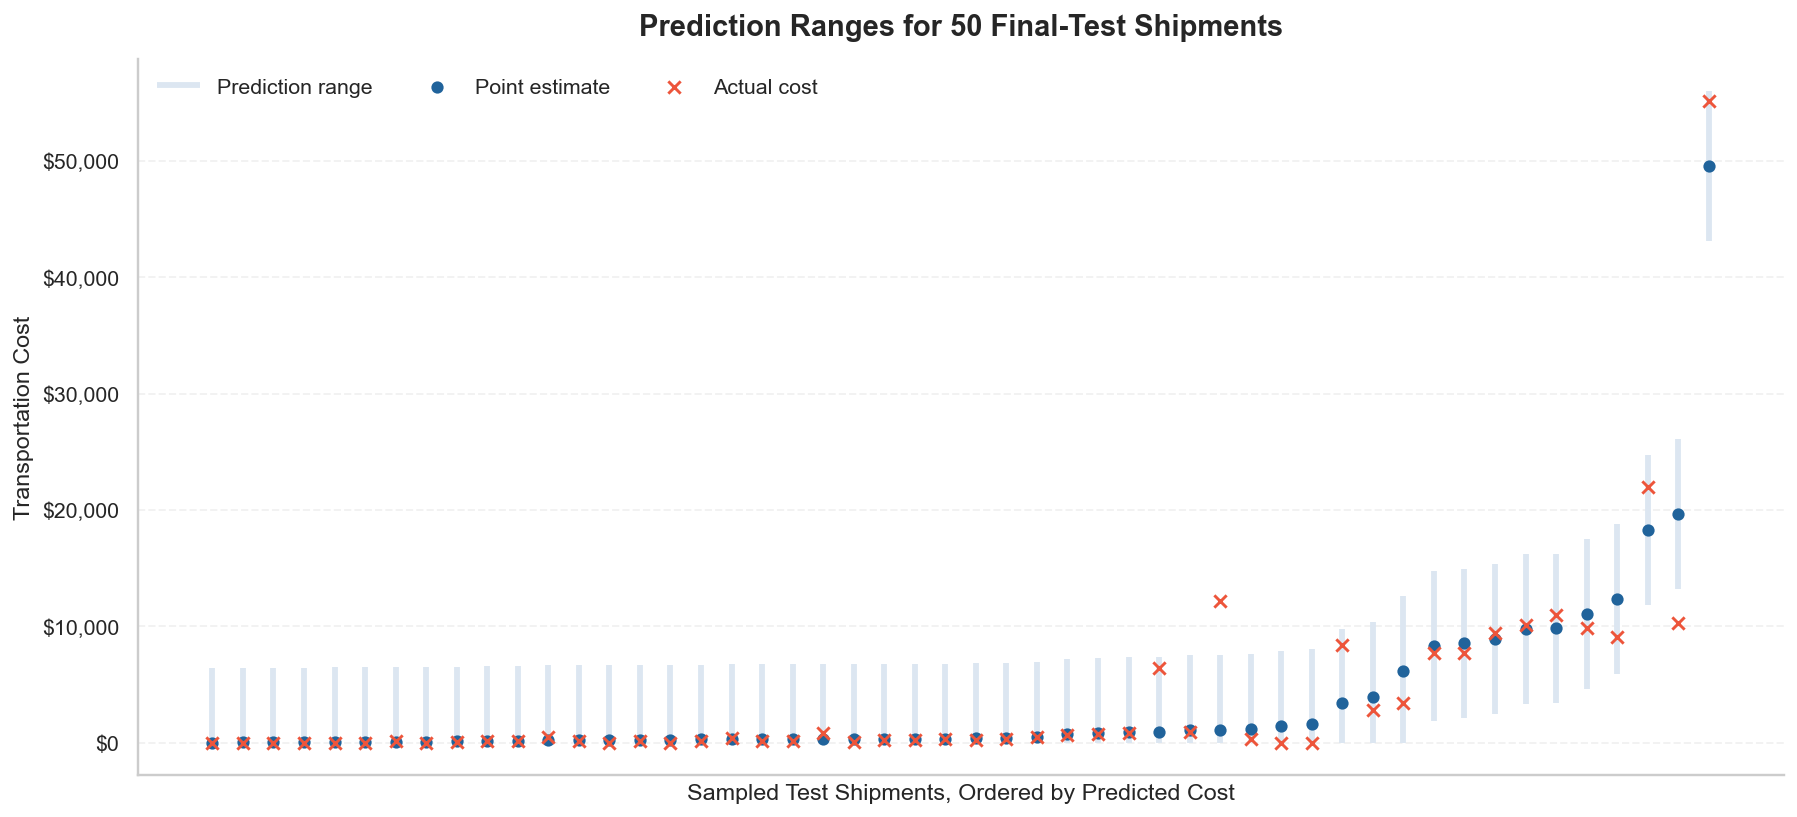

In [63]:
interval_plot = interval_diagnostics.sample(
    n=min(50, len(interval_diagnostics)), random_state=RANDOM_STATE
).sort_values("Prediction").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6), dpi=140)
x = np.arange(len(interval_plot))
ax.vlines(x, interval_plot["Lower"], interval_plot["Upper"], color=COLORS["light"], linewidth=3, label="Prediction range")
ax.scatter(x, interval_plot["Prediction"], color=COLORS["blue"], s=28, label="Point estimate", zorder=3)
ax.scatter(x, interval_plot["Actual"], color=COLORS["red"], marker="x", s=40, label="Actual cost", zorder=4)
ax.yaxis.set_major_formatter(currency)
ax.set_title("Prediction Ranges for 50 Final-Test Shipments", fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Sampled Test Shipments, Ordered by Predicted Cost")
ax.set_ylabel("Transportation Cost")
ax.set_xticks([])
ax.legend(frameon=False, ncol=3, loc="upper left")
clean_axes(ax, "y")
plt.tight_layout(); plt.show()

In [64]:
sample_coverage = interval_plot["Covered"].mean()
sample_misses = (~interval_plot["Covered"]).sum()
display(Markdown(f'''
**Visualization analysis.** In this reproducible sample, **{interval_plot['Covered'].sum()} of {len(interval_plot)} shipments ({sample_coverage:.1%})** fall inside their prediction ranges and **{sample_misses}** fall outside. Wider vertical lines communicate greater dollar uncertainty. The production decision should rely on full-test coverage—not only this visual sample—but the chart makes the meaning of a quote range tangible for brokers.
'''))


**Visualization analysis.** In this reproducible sample, **48 of 50 shipments (96.0%)** fall inside their prediction ranges and **2** fall outside. Wider vertical lines communicate greater dollar uncertainty. The production decision should rely on full-test coverage—not only this visual sample—but the chart makes the meaning of a quote range tangible for brokers.


## 8.4 Operational Acceptance Check

The following cell summarizes whether the first range model meets its requested 90% overall test coverage. Passing this check does not guarantee equal performance for every transport type, branch, or cost level; the segment diagnostics above remain part of the acceptance decision.

In [65]:
coverage_tolerance = 0.02
coverage_pass = empirical_coverage >= COVERAGE - coverage_tolerance

acceptance = pd.Series({
    "Model": best_candidate_name,
    "Requested Coverage": COVERAGE,
    "Observed Test Coverage": empirical_coverage,
    "Coverage Tolerance": coverage_tolerance,
    "Coverage Check": "PASS" if coverage_pass else "REVIEW / RECALIBRATE",
    "Point Prediction MAE": test_metrics.iloc[0]["MAE"],
    "Average Range Width": average_width,
    "Conformal Margin": conformal_margin,
})
display(acceptance.to_frame("Result"))

,Result
Model,Extra Trees
Requested Coverage,0.9
Observed Test Coverage,0.893123
Coverage Tolerance,0.02
Coverage Check,PASS
Point Prediction MAE,3279.553161
Average Range Width,8972.647431
Conformal Margin,6439.38246


In [66]:
decision_text = (
    "The first interval model passes the overall coverage check and can proceed to controlled pilot testing."
    if coverage_pass else
    "The first interval model does not reach the acceptable overall coverage threshold and should be recalibrated before pilot use."
)
display(Markdown(f'''
**Acceptance conclusion.** {decision_text} Observed coverage is **{empirical_coverage:.1%}** against a requested **{COVERAGE:.0%}**, with an average range width of **${average_width:,.2f}**. Even if overall coverage passes, branches or transport types below target should be flagged during the pilot.
'''))


**Acceptance conclusion.** The first interval model passes the overall coverage check and can proceed to controlled pilot testing. Observed coverage is **89.3%** against a requested **90%**, with an average range width of **$8,972.65**. Even if overall coverage passes, branches or transport types below target should be flagged during the pilot.


## Final Prediction-Range Decision

The 90% split-conformal interval achieved **89.31% observed coverage** on the untouched chronological test period. This is only **0.69 percentage points below** the requested 90% and remains within the project’s predefined two-percentage-point tolerance. Therefore, the first interval model **passes the overall coverage check** and can proceed to controlled pilot testing.

- **Requested coverage:** 90.00%
- **Observed test coverage:** 89.31%
- **Conformal margin:** $6,439.38
- **Average interval width:** $8,972.65

The conformal method begins with a constant margin of approximately **$6,439 on each side** of the point estimate. However, the average final width is less than twice that amount because lower limits are capped at zero for inexpensive predictions. The resulting ranges protect against most historical errors, but they may be operationally wide for lower-cost shipments.

The range is suitable as transparent decision support—not as a guaranteed charge. Before full deployment, the company should pilot the tool and monitor coverage and range width by transport type, branch, route frequency, and cost level. If expensive shipments fall below target coverage or inexpensive shipments receive unhelpfully broad ranges, a second iteration should use normalized or segment-specific conformal calibration.

## 8.5 Export the Trained Model for the Broker Quote Tool

The application needs the fitted preprocessing pipeline, tuned Extra Trees model, conformal margin, feature order, and valid dropdown options. The following cell saves them together as a single `joblib` bundle. Run it after all modeling and interval cells have completed successfully.

In [67]:
import joblib

category_options = {
    col: sorted(model_df[col].dropna().astype(str).unique().tolist())
    for col in categorical_features
    if col != "Route"
}

model_bundle = {
    "model": best_model,
    "conformal_margin": float(conformal_margin),
    "coverage": float(COVERAGE),
    "features": features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "category_options": category_options,
    "final_test_metrics": test_metrics.to_dict(orient="index"),
    "model_name": best_candidate_name,
}

MODEL_BUNDLE_PATH = Path("shipping_cost_model_bundle.joblib")
joblib.dump(model_bundle, MODEL_BUNDLE_PATH)
print(f"Model bundle saved to: {MODEL_BUNDLE_PATH.resolve()}")

Model bundle saved to: C:\Users\thati\Documents\Codex\2026-08-16\h\outputs\New folder\Shipment-Cost-Quote-Tool-COMPLETE\shipping_cost_model_bundle.joblib


# 9. Final Conclusions and Recommendations

## Selected Model: Tuned Extra Trees

The **tuned Extra Trees regressor** was selected as the final point-prediction model because it achieved the lowest chronological validation MAE among the eligible candidates and maintained the strongest performance after hyperparameter tuning. Model selection was based on performance on future time periods rather than on the training data, which provides a more realistic evaluation of how the solution would behave when brokers prepare new quotes.

On the untouched final test period, the selected model achieved an **MAE of $3,279.55**, a **median absolute error of $534.79**, an **RMSE of $11,551.79**, and an **R-squared of 0.425**. The median error shows that the model is reasonably close for many routine shipments, while the larger MAE and RMSE reveal that uncommon or high-cost shipments can still produce substantial errors. For this reason, the model should not be presented as a guaranteed final charge.

## Main Conclusions

1. Historical shipment information available at quote time contains useful patterns for estimating final transportation cost. Transport type, shipment mode, route, branch, weight, volume, containerization, and timing all contribute business-relevant information.
2. Transportation costs are highly variable and right-skewed. Typical shipments are estimated more accurately than rare or unusually expensive shipments, which explains the difference between the median absolute error and the overall MAE and RMSE.
3. A prediction range is more appropriate for the business objective than a single point estimate. The 90% split-conformal range captured the actual final cost for **89.31%** of shipments in the untouched test period, within the predefined two-percentage-point acceptance tolerance.
4. The solution is designed to support broker judgment, not replace it. The estimated cost and range provide a consistent starting point, while brokers remain responsible for reviewing unusual routes, missing information, expensive shipments, and known operational disruptions.
5. The completed prototype demonstrates that the model can be translated into a practical quote-support tool using information brokers already have when preparing a customer quote.

## Business Recommendations

- Conduct a **controlled 90-day pilot** with a small group of brokers before broader deployment.
- Use the tool for routine quotes and require human review when the suggested range is wide, the route is uncommon, critical information is missing, or the shipment is unusually expensive.
- Track range coverage, range width, quote preparation time, broker adoption, quote adjustments, and unrecovered transportation costs during the pilot.
- Compare every tool-assisted estimate with the finalized transportation cost so performance can be monitored by transport type, branch, route frequency, and cost level.
- Recalibrate the model and prediction ranges periodically as new finalized shipment data becomes available or when business conditions change.
- Consider segment-specific ranges in a future iteration if lower-cost shipments receive ranges that are too wide or high-cost shipments remain more difficult to cover.

## Final Recommendation

Gallagher Transport International should pilot the transportation-cost quote assistant as a **decision-support tool for freight brokers**. The solution can help brokers prepare faster and more consistent customer quotes, communicate uncertainty transparently, and reduce avoidable margin surprises. Full implementation should depend on the results of the controlled pilot and continued human review of unusual shipments.

---

**Project:** Transportation Cost Prediction Using Machine Learning  
**Author:** Maryi Tatiana Palacios Giraldo  
**Program:** MSDS 696 - Practicum II, Regis University  
**Date:** August 2026